In [1]:
from pathlib import Path

data_root = Path("E:\Compressed\Thermal Image dataset for object classification\Dataset")   # مسیر دقیق را بگذار

print("=== Directories ===")
for p in sorted(data_root.rglob("*")):
    if p.is_dir():
        print(p.relative_to(data_root))

print("\n=== Sample files ===")
for p in list(data_root.rglob("*"))[:30]:
    if p.is_file():
        print(p.relative_to(data_root), "→", p.suffix)

=== Directories ===
FLIR
FLIR\Test
FLIR\Test\car
FLIR\Test\cat
FLIR\Test\man
FLIR\Train
FLIR\Train\car
FLIR\Train\cat
FLIR\Train\man
SeekThermal
SeekThermal\Test
SeekThermal\Test\car
SeekThermal\Test\cat
SeekThermal\Test\man
SeekThermal\Train
SeekThermal\Train\Car
SeekThermal\Train\Cat
SeekThermal\Train\Man

=== Sample files ===
FLIR\Test\car\flir_20200116T174847.jpg → .jpg
FLIR\Test\car\flir_20200116T174848.jpg → .jpg
FLIR\Test\car\flir_20200116T174853.jpg → .jpg
FLIR\Test\car\flir_20200116T174857.jpg → .jpg
FLIR\Test\car\flir_20200116T174911.jpg → .jpg
FLIR\Test\car\flir_20200116T174913.jpg → .jpg
FLIR\Test\car\flir_20200116T174921 (2).jpg → .jpg
FLIR\Test\car\flir_20200116T174921.jpg → .jpg
FLIR\Test\car\flir_20200116T174924 (2).jpg → .jpg
FLIR\Test\car\flir_20200116T174924.jpg → .jpg
FLIR\Test\car\flir_20200116T174925 (2).jpg → .jpg
FLIR\Test\car\flir_20200116T174929 (2).jpg → .jpg
FLIR\Test\car\flir_20200116T174929.jpg → .jpg
FLIR\Test\car\flir_20200116T174930 (2).jpg → .jpg
FLIR\

In [2]:
import os
import time
import copy
import json
from dataclasses import dataclass, asdict
from torch.utils.data import Subset, random_split   # این دو تا رو اگر هنوز وارد نکردی، اضافه کن

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import pennylane as qml

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder

from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

torch.set_float32_matmul_precision('high')


import matplotlib.pyplot as plt

from PIL import Image

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PyTorch: 2.7.1+cu118
CUDA available: True
Device: cuda


In [3]:
@dataclass
class ExperimentConfig:
    seed: int = 42

    # Dataset
    dataset_root: str = r"E:\Compressed\Thermal Image dataset for object classification\Dataset\SeekThermal"
    train_dir: str = None          # بعداً در __post_init__ پر می‌شود
    test_dir: str = None
    val_ratio: float = 0.15
    img_h: int = 128
    img_w: int = 96
    num_classes: int = 3

    # Training
    batch_size: int = 64  # مناسب برای پایداری Amplitude QNN
    epochs: int = 10
    lr: float = 1e-3
    weight_decay: float = 1e-4
    optimizer_name: str = "adamw"
    scheduler_name: str = "cosine"
    num_workers: int = 0  # 0 برای جلوگیری از Deadlock در پردازش کوانتومی چندرشته‌ای
    zz_scale: float = 0.25

    # Feature / Quantum
    feature_dim: int = 64
    spatial_h: int = 16
    spatial_w: int = 12
    n_qubits: int = 6
    n_q_layers: int = 3
    n_parallel: int = 3
    q_device_name: str = "default.qubit"
    shots: int = None
    zz_scale: float = 0.25

    # Runtime
    use_amp: bool = False
    save_dir: str = "./results_hybrid_SeekThermal_parallel"

    def __post_init__(self):
        from pathlib import Path
        root = Path(self.dataset_root)
        self.train_dir = root / "Train"
        self.test_dir  = root / "Test"
        assert 2 ** self.n_qubits == self.feature_dim, \
            f"feature_dim ({self.feature_dim}) must equal 2**n_qubits ({2**self.n_qubits})"

cfg = ExperimentConfig()

In [4]:
# =========================================================
# Configuration
# =========================================================

SEED = 42

# Dataset
DATASET_ROOT = Path("E:\\Compressed\\Thermal Image dataset for object classification\\Dataset\\SeekThermal")

TRAIN_DIR = DATASET_ROOT / "Train"
TEST_DIR  = DATASET_ROOT / "Test"

# Image size
IMG_W = 96
IMG_H = 128



# Classes
NUM_CLASSES = 3
CLASS_NAMES = ["Car", "Cat", "Man"]

# Training
batch_size: int = 64  # مناسب برای پایداری Amplitude QNN
epochs: int = 10
lr: float = 1e-3
weight_decay: float = 1e-5
optimizer_name: str = "adamw"
scheduler_name: str = "cosine"
num_workers: int = 0  # 0 برای جلوگیری از Deadlock در پردازش کوانتومی چندرشته‌ای
zz_scale: float = 0.25

# Feature Dimensions
feature_dim: int = 64  # بعد بردار نهایی برای Amplitude (2**6) یا Angle

# Spatial Feature Map Grid (ابعاد فیزیکی خروجی انکودر کانولوشنی)
spatial_h: int = 8
spatial_w: int = 8

# Quantum
n_qubits: int = 6       # برای Amplitude: 2**7 = 128
n_q_layers: int = 3
n_parallel: int = 3
q_device_name: str = "default.qubit"
shots: int = None

# Runtime
use_amp: bool = False
save_dir: str = "./results_hybrid_SeekThermal_parallel"


print("Train:", TRAIN_DIR)
print("Test :", TEST_DIR)
print("Image:", IMG_W, "x", IMG_H)

Train: E:\Compressed\Thermal Image dataset for object classification\Dataset\SeekThermal\Train
Test : E:\Compressed\Thermal Image dataset for object classification\Dataset\SeekThermal\Test
Image: 96 x 128


In [5]:
import random
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

In [6]:
print('dataset root:', DATASET_ROOT.exists())
print("Train exists  :", TRAIN_DIR.exists())
print("Test exists   :", TEST_DIR.exists())

print("\nTrain classes:")
if TRAIN_DIR.exists():
    for p in sorted(TRAIN_DIR.iterdir()):
        if p.is_dir():
            print("-", p.name, "→", len(list(p.glob("*"))), "images")
            
print("\nTest classes:")
if TEST_DIR.exists():
    for p in sorted(TEST_DIR.iterdir()):
        if p.is_dir():
            print("-", p.name, "→", len(list(p.glob("*"))), "images")    

dataset root: True
Train exists  : True
Test exists   : True

Train classes:
- Car → 1168 images
- Cat → 1782 images
- Man → 1782 images

Test classes:
- car → 356 images
- cat → 356 images
- man → 356 images


In [7]:

train_transform = transforms.Compose([
    transforms.Resize((IMG_H, IMG_W)),



    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_H, IMG_W)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_H, IMG_W)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])


In [8]:
import numpy as np

from torchvision import datasets
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split


# =========================================================
# 1) Base dataset فقط برای ساخت stratified split
# =========================================================

base_dataset = datasets.ImageFolder(root=TRAIN_DIR)

indices = np.arange(len(base_dataset))
targets = np.array(base_dataset.targets)

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.15,
    random_state=42,
    stratify=targets
)


# =========================================================
# 2) Datasetهای واقعی با Transform مجزا
# =========================================================

# train و validation هر دو از TRAIN_DIR می‌آیند،
# ولی transform متفاوت دارند.
train_dataset = Subset(
    datasets.ImageFolder(
        root=TRAIN_DIR,
        transform=train_transform
    ),
    train_idx
)

val_dataset = Subset(
    datasets.ImageFolder(
        root=TRAIN_DIR,
        transform=val_transform
    ),
    val_idx
)

# test از مسیر مستقل
test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_transform
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))


Train samples: 4022
Validation samples: 710
Test samples: 1068


In [9]:
# =========================================================
# Fix swapped Car <-> Cat folders
# =========================================================

# وضعیت فعلی ImageFolder:
# train: {'Car': 0, 'Cat': 1, 'Man': 2}
# test : {'car': 0, 'cat': 1, 'man': 2}

# واقعیت محتوا:
# پوشه Car  → تصاویر گربه  → باید لیبل Cat (1) شود
# پوشه Cat  → تصاویر ماشین → باید لیبل Car (0) شود
# پوشه Man  → درست است

def fix_swapped_labels(dataset):
    # نقشه‌ی اصلاح: لیبل فعلی → لیبل صحیح
    remap = {0: 1, 1: 0, 2: 2}   # Car↔Cat ، Man بدون تغییر
    
    # اصلاح samples
    new_samples = []
    for path, label in dataset.samples:
        new_samples.append((path, remap[label]))
    dataset.samples = new_samples
    
    # اصلاح targets (اگر وجود داشته باشد)
    if hasattr(dataset, 'targets'):
        dataset.targets = [remap[t] for t in dataset.targets]
    
    # اصلاح class_to_idx و classes (اختیاری ولی تمیزتر است)
    # می‌خواهیم ترتیب نهایی این باشد: Car=0, Cat=1, Man=2
    dataset.class_to_idx = {'Car': 0, 'Cat': 1, 'Man': 2}
    dataset.classes = ['Car', 'Cat', 'Man']
    
    return dataset


# =========================================================
# Apply Fix
# =========================================================

# train_dataset و val_dataset از نوع Subset هستند.
# ImageFolder اصلی در train_dataset.dataset قرار دارد.
fix_swapped_labels(train_dataset.dataset)
fix_swapped_labels(val_dataset.dataset)

# test_dataset خودش ImageFolder است.
# این خط را فقط وقتی نگه دار که فولدرهای TEST هم واقعاً
# Car و Cat را به‌صورت محتوایی جابه‌جا دارند.
#fix_swapped_labels(test_dataset)


# =========================================================
# Verify class mapping
# =========================================================

print("After fix:")

print("train class_to_idx:", train_dataset.dataset.class_to_idx)
print("val   class_to_idx:", val_dataset.dataset.class_to_idx)
print("test  class_to_idx:", test_dataset.class_to_idx)

print("train classes:", train_dataset.dataset.classes)
print("val   classes:", val_dataset.dataset.classes)
print("test  classes:", test_dataset.classes)


# Subset دارای classes نیست؛ باید از .dataset بخوانیم.
train_class = [c.lower() for c in train_dataset.dataset.classes]
val_class   = [c.lower() for c in val_dataset.dataset.classes]

# test_dataset مستقیماً ImageFolder است.
test_class  = [c.lower() for c in test_dataset.classes]

print("\ntrain_class:", train_class)
print("val_class  :", val_class)
print("test_class :", test_class)

assert train_class == val_class, "Train and Validation classes do not match!"
assert train_class == test_class, "Train and Test classes do not match!"

print("\n✅ Class mapping is consistent.")


After fix:
train class_to_idx: {'Car': 0, 'Cat': 1, 'Man': 2}
val   class_to_idx: {'Car': 0, 'Cat': 1, 'Man': 2}
test  class_to_idx: {'car': 0, 'cat': 1, 'man': 2}
train classes: ['Car', 'Cat', 'Man']
val   classes: ['Car', 'Cat', 'Man']
test  classes: ['car', 'cat', 'man']

train_class: ['car', 'cat', 'man']
val_class  : ['car', 'cat', 'man']
test_class : ['car', 'cat', 'man']

✅ Class mapping is consistent.


In [10]:

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers
)


In [11]:
image,lable = next(iter(train_loader))

print("image shape:", image.shape)
print("lable shape:", lable.shape)

print("image dtype:", image.dtype)
print("lable dtype:", lable.dtype)

print("image min:", image.min().item())
print("image max:", image.max().item())



image shape: torch.Size([64, 3, 128, 96])
lable shape: torch.Size([64])
image dtype: torch.float32
lable dtype: torch.int64
image min: -1.0
image max: 1.0


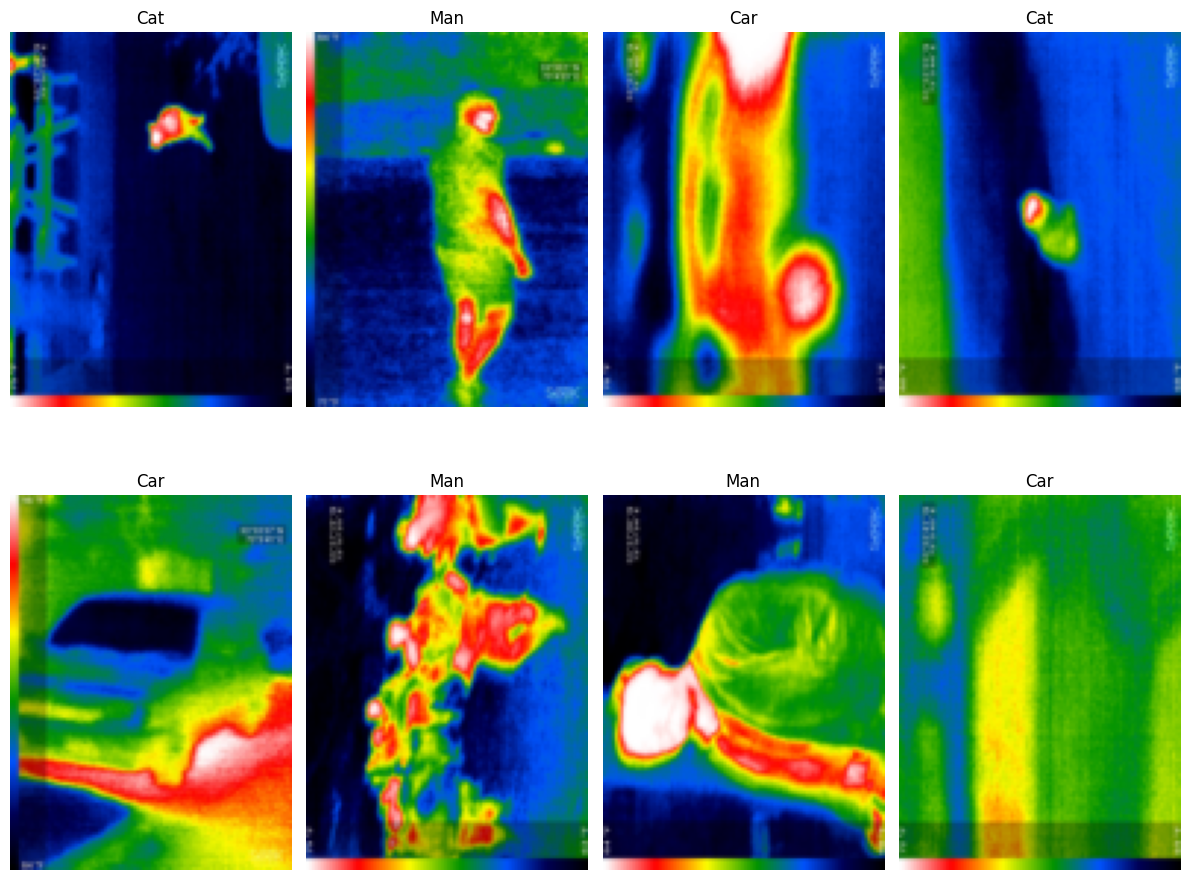

In [12]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 10))

for i, ax in enumerate(axes.flat):

    # CHW → HWC
    img = images[i].permute(1, 2, 0).numpy()

    # اگر Normalize انجام داده‌ایم، برای نمایش برگردان به [0,1]
    img = np.clip(img * 0.5 + 0.5, 0, 1)

    ax.imshow(img)
    ax.set_title(train_dataset.dataset.classes[labels[i].item()])
    ax.axis("off")

plt.tight_layout()
plt.show()

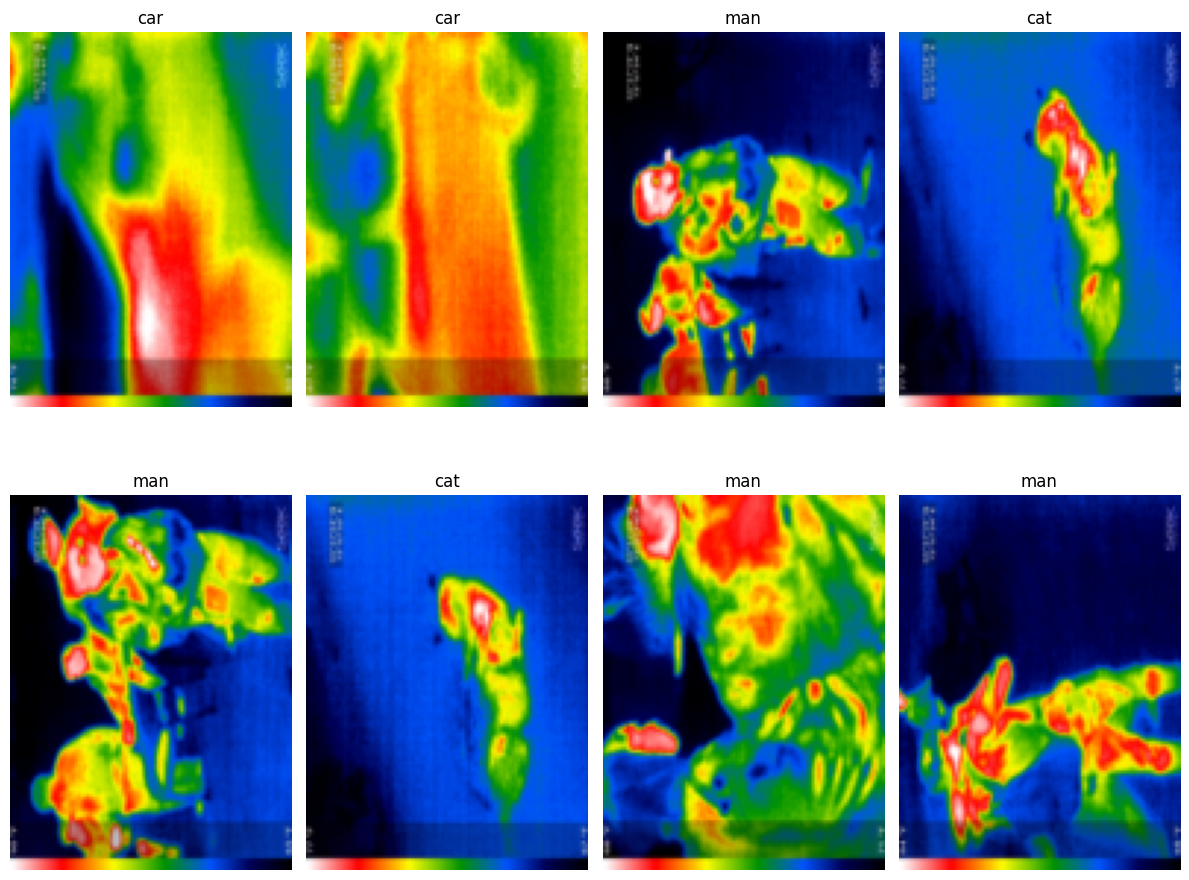

In [13]:
images, labels = next(iter(test_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 10))

for i, ax in enumerate(axes.flat):

    # CHW → HWC
    img = images[i].permute(1, 2, 0).numpy()

    # اگر Normalize انجام داده‌ایم، برای نمایش برگردان به [0,1]
    img = np.clip(img * 0.5 + 0.5, 0, 1)

    ax.imshow(img)
    ax.set_title(test_dataset.classes[labels[i].item()])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [14]:
class ClassicalBackbone(nn.Module):

    def __init__(self, in_channels=1, feature_dim=32, use_projector=True):
        super().__init__()

        self.encoder = nn.Sequential(

            # -----------------------------------------
            # Input: 3 × 96 × 128
            # Output: 16 × 48 × 64
            # -----------------------------------------
            nn.Conv2d(
                in_channels,
                16,
                kernel_size=3,
                padding=1,
                bias=True
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # -----------------------------------------
            # Output: 32 × 24 × 32
            # -----------------------------------------
            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1,
                bias=True
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # -----------------------------------------
            # Output: 64 × 12 × 16
            # -----------------------------------------
            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1,
                bias=True
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # -----------------------------------------
            # Output: 64 × 12 × 16
            # -----------------------------------------
            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                padding=1,
                bias=True
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

        )

        self.out_channels = 64
        self.pool = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4))
        )

        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, 32, 32)
            feat = self.pool(self.encoder(dummy))
            flat_dim = feat.view(1, -1).shape[1]
        
        if use_projector:
            self.projector = nn.Sequential(
                nn.Flatten(),
                nn.Linear(flat_dim, feature_dim),
            )
        else:
            self.projector = None

    def forward(self, x):

        x = x.float()
 
        feature_map = self.encoder(x)

        pooled = self.pool(feature_map)
        if self.projector is not None:
            feature_vec = self.projector(pooled)
        else:
            feature_vec = None

        return feature_vec, feature_map

In [15]:
import math
import torch


def _first_n_primes(n: int):
    primes = []
    x = 2
    while len(primes) < n:
        is_prime = True
        r = int(math.sqrt(x)) + 1
        for p in range(2, r):
            if x % p == 0:
                is_prime = False
                break
        if is_prime:
            primes.append(x)
        x += 1
    return primes


def _coprime_geq(start: int, n: int):
    x = max(1, start)
    while math.gcd(x, n) != 1:
        x += 1
    return x


def _grid_identity(h, w):
    return torch.arange(h * w, dtype=torch.long)


def _grid_reverse(h, w):
    return torch.arange(h * w - 1, -1, -1, dtype=torch.long)


def _grid_serpentine(h, w):
    rows = []
    for r in range(h):
        if r % 2 == 0:
            row = torch.arange(r * w, (r + 1) * w, dtype=torch.long)
        else:
            row = torch.arange((r + 1) * w - 1, r * w - 1, -1, dtype=torch.long)
        rows.append(row)
    return torch.cat(rows)


def _grid_col_major(h, w):
    return (torch.arange(w)[None, :] * h + torch.arange(h)[:, None]).reshape(-1).long()


def _grid_col_major_reverse_cols(h, w):
    col_order = torch.arange(w - 1, -1, -1)
    return (col_order[None, :] * h + torch.arange(h)[:, None]).reshape(-1).long()


def _grid_checkerboard(h, w):
    coords = [(r, c) for r in range(h) for c in range(w)]
    even = [r * w + c for r, c in coords if (r + c) % 2 == 0]
    odd = [r * w + c for r, c in coords if (r + c) % 2 == 1]
    return torch.tensor(even + odd, dtype=torch.long)


def _grid_row_shift_prime(h, w, p):
    rows = []
    for r in range(h):
        shift = (r * p) % w
        cols = (torch.arange(w) + shift) % w
        rows.append(r * w + cols)
    return torch.cat(rows).long()


def _grid_col_shift_prime(h, w, p):
    cols = []
    for c in range(w):
        shift = (c * p) % h
        rows = (torch.arange(h) + shift) % h
        cols.append(rows * w + c)
    return torch.cat(cols).long()


def _grid_affine_flat(h, w, a, b):
    n = h * w
    idx = torch.arange(n, dtype=torch.long)
    return ((a * idx + b) % n).long()


def _grid_diagonal_wrap(h, w, p):
    used = torch.zeros(h, w, dtype=torch.bool)
    out = []

    for start in range(h + w - 1):
        diag = []
        for r in range(h):
            c = start - r
            if 0 <= c < w:
                diag.append((r, c))

        if len(diag) == 0:
            continue

        shift = p % len(diag)
        diag = diag[shift:] + diag[:shift]

        for r, c in diag:
            if not used[r, c]:
                out.append(r * w + c)
                used[r, c] = True

    return torch.tensor(out, dtype=torch.long)


def make_spatial_permutations(h=8, w=8, n_heads=8):
    """
    تولید permutation برای هر تعداد head به صورت deterministic و scalable.

    خروجی:
        perms[head_idx] -> torch.LongTensor of shape [h*w]
    """
    n = h * w
    primes = _first_n_primes(max(n_heads * 2, 16))

    families = [
        "identity",
        "serpentine",
        "checkerboard",
        "row_shift_prime",
        "col_shift_prime",
        "col_major_reverse",
        "reverse",
        "affine_flat",
        "diagonal_wrap",
    ]

    perms = []
    seen = set()

    for head in range(n_heads):
        family = families[head % len(families)]
        p = primes[head]
        q = primes[head + 1]

        if family == "identity":
            perm = _grid_identity(h, w)

        elif family == "serpentine":
            perm = _grid_serpentine(h, w)

        elif family == "checkerboard":
            perm = _grid_checkerboard(h, w)

        elif family == "row_shift_prime":
            perm = _grid_row_shift_prime(h, w, p)

        elif family == "col_shift_prime":
            perm = _grid_col_shift_prime(h, w, p)

        elif family == "col_major_reverse":
            perm = _grid_col_major_reverse_cols(h, w)

        elif family == "reverse":
            perm = _grid_reverse(h, w)

        elif family == "affine_flat":
            a = _coprime_geq(p, n)
            b = q % n
            perm = _grid_affine_flat(h, w, a, b)

        elif family == "diagonal_wrap":
            perm = _grid_diagonal_wrap(h, w, p)

        else:
            perm = _grid_identity(h, w)

        key = tuple(perm.tolist())

        # اگر تکراری شد، fallback به affine جدید
        if key in seen:
            a = _coprime_geq(p + head + 1, n)
            b = (q + head * 7) % n
            perm = _grid_affine_flat(h, w, a, b)
            key = tuple(perm.tolist())

        seen.add(key)
        perms.append(perm)

    return perms


In [42]:
import numpy as np
import pennylane as qml
import torch
import torch.nn as nn

# =========================================================
# Updated Entanglement Patterns (Dynamic Routing / Imprinting)
# =========================================================

def ring_entanglement(n_qubits, shift=0):
    """Circular / Ring – با پشتیبانی از شیفت داینامیک"""
    for q in range(n_qubits):
        src = q
        tgt = (q + 1 + shift) % n_qubits
        if src != tgt:
            qml.CNOT(wires=[src, tgt])


def pairwise_entanglement(n_qubits, shift=0):
    """Pairwise – با پشتیبانی از شیفت داینامیک"""
    # لایه اول: زوج‌ها
    for q in range(0, n_qubits - 1, 2):
        src = q
        tgt = (q + 1 + shift) % n_qubits
        if src != tgt:
            qml.CNOT(wires=[src, tgt])
    # لایه دوم: فردها
    for q in range(1, n_qubits - 1, 2):
        src = q
        tgt = (q + 1 + shift) % n_qubits
        if src != tgt:
            qml.CNOT(wires=[src, tgt])


def ring_skip_entanglement(n_qubits, shift=0):
    """Circular + long-range skip (فاصله ۲) – با پشتیبانی از شیفت داینامیک"""
    for q in range(n_qubits):
        src = q
        tgt1 = (q + 1 + shift) % n_qubits
        tgt2 = (q + 2 + shift) % n_qubits
        if src != tgt1:
            qml.CNOT(wires=[src, tgt1])
        if src != tgt2:
            qml.CNOT(wires=[src, tgt2])

# لیست الگوها برای n_parallel تا head
ENTANGLEMENT_PATTERNS = [ring_entanglement, pairwise_entanglement, ring_skip_entanglement]

# =========================================================
# Hybrid QNode Factory
# =========================================================

class HybridQNodeFactory:
    """یک QNode برداری برای هر mode می‌سازد (نسخه دو-Rotation با Imprinting Shift)."""

    SUPPORTED_MODES = {
        "amplitude",
        "zz",
        "dense_angle",
    }

    def __init__(self, cfg, mode, head_idx=0):
        if mode not in self.SUPPORTED_MODES:
            raise ValueError(
                f"Unknown mode={mode!r}; "
                f"expected one of {sorted(self.SUPPORTED_MODES)}"
            )

        self.cfg = cfg
        self.mode = mode
        self.head_idx = head_idx
        self.n_qubits = cfg.n_qubits
        self.n_layers = cfg.n_q_layers

        self.dev = qml.device(
            cfg.q_device_name,
            wires=self.n_qubits,
            shots=cfg.shots,
        )

        self.ring_pairs = tuple(
            (q, (q + 1) % self.n_qubits)
            for q in range(self.n_qubits)
        )

        self.zz_pairs = tuple(
            (i, j)
            for i in range(self.n_qubits)
            for j in range(i + 1, self.n_qubits)
        )

        self.qnode = self._build_qnode()

    def _build_qnode(self):
        mode = self.mode
        n_qubits = self.n_qubits
        n_layers = self.n_layers
        head_idx = self.head_idx
        # شدت interaction داده‌محور ZZ
        zz_scale = float(getattr(self.cfg, "zz_scale", 0.25))

        # جلوگیری از مقدار نامعتبر
        if zz_scale < 0.0:
            raise ValueError("cfg.zz_scale باید بزرگ‌تر یا مساوی صفر باشد.")

        @qml.qnode(
            self.dev,
            interface="torch",
            diff_method="backprop",
        )
        def circuit(feat_batch, amp_batch, weight_batch):
            """
            weight_batch باید شکل زیر را داشته باشد:
            (N, n_layers, 2, n_qubits, 3)
            """

            # -------------------------------------------------------
            # Embedding اولیه
            # -------------------------------------------------------
            if mode == "amplitude":
                qml.AmplitudeEmbedding(
                    features=amp_batch,
                    wires=range(n_qubits),
                    normalize=True,
                    pad_with=0.0,
                )

            # -------------------------------------------------------
            # لایه‌های variational: Rot → Ent → Rot
            # -------------------------------------------------------
            entangle_fn = ENTANGLEMENT_PATTERNS[head_idx % len(ENTANGLEMENT_PATTERNS)]

            for layer in range(n_layers):
                # Encoding data in eath layer (برای modeهای dense_angle و zz)
                
                if mode == "dense_angle":
                    chunk = feat_batch[:, layer, :]              # (B, 2*n_qubits)  -- Comment fix: technically 3*n_qubits for dense_angle
                    chunk = (chunk - chunk.mean(dim=-1, keepdim=True)) / (chunk.std(dim=-1, keepdim=True) + 1e-6)  # نرمال‌سازی

                    angles_y = torch.tanh(chunk[:, :n_qubits]) * torch.pi
                    #angles_z = torch.tanh(chunk[:, n_qubits:2*n_qubits]) * torch.pi
                    angles_x = torch.tanh(chunk[:,  n_qubits:]) * torch.pi

                    if layer == 0:
                        for q in range(n_qubits):
                            qml.Hadamard(wires=q)

                    for q in range(n_qubits):
                        qml.RX(angles_x[:, q], wires=q)
                        qml.RY(angles_y[:, q], wires=q)
                        j = (q + 1) % n_qubits

                        # interaction دو feature مجاور
                        phi = (
                            zz_scale
                            * angles_x[:, q]
                            * angles_y[:, j]
                            / torch.pi
                        )

                        qml.CNOT(wires=[q, j])

                        qml.RZ(
                            2.0 * phi,
                            wires=j,
                        )                        
                        qml.CNOT(wires=[q, j])
                        #qml.RZ(angles_z[:, q], wires=q)


                # ========== Re-uploading مخصوص ZZ ==========
                if mode == "zz":
                    # feat_batch: (B, n_layers, 2 * n_qubits)
                    raw = feat_batch[:, layer, :]

                    if raw.shape[-1] != 2 * n_qubits:
                        raise ValueError(
                            "برای mode='zz' انتظار می‌رود آخرین بعد feat_batch "
                            f"برابر 2*n_qubits باشد، اما shape={raw.shape}"
                        )

                    # --------------------------------------------------
                    # نرمال‌سازی مشترک دو کانال هر layer
                    # --------------------------------------------------
                    raw = (
                        raw - raw.mean(dim=-1, keepdim=True)
                    ) / (
                        raw.std(dim=-1, keepdim=True) + 1e-6
                    )

                    # --------------------------------------------------
                    # جداسازی دو embedding مستقل برای هر qubit
                    # --------------------------------------------------
                    angles_y = torch.tanh(raw[:, :n_qubits]) * torch.pi
                    angles_z = torch.tanh(raw[:, n_qubits:]) * torch.pi

                    # آماده‌سازی superposition فقط در ابتدای مدار
                    if layer == 0:
                        for q in range(n_qubits):
                            qml.Hadamard(wires=q)

                    # Embedding اول و دوم روی هر qubit
                    for q in range(n_qubits):
                        qml.RY(angles_y[:, q], wires=q)
                        qml.RZ(angles_z[:, q], wires=q)

                    # Data-dependent Ring ZZ
                    if n_qubits > 1:
                        for q in range(n_qubits):
                            j = (q + 1) % n_qubits
                            phi = (
                                zz_scale
                                * angles_z[:, q]
                                * angles_z[:, j]
                                / torch.pi
                            )
                            qml.CNOT(wires=[q, j])
                            qml.RZ(2.0 * phi, wires=j)
                            qml.CNOT(wires=[q, j])

                # ========== بلوک variational (همه modeها) ==========
                
                # 1. Rotation اول
                for q in range(n_qubits):
                    qml.Rot(
                        weight_batch[..., layer, 0, q, 0],
                        weight_batch[..., layer, 0, q, 1],
                        weight_batch[..., layer, 0, q, 2],
                        wires=q,
                    )

                # 2. Entanglement (اعمال شیفت داینامیک بر اساس لایه فعلی)
                current_shift = layer % n_qubits
                entangle_fn(n_qubits, shift=current_shift)

                # 3. Rotation دوم
                for q in range(n_qubits):
                    qml.Rot(
                        weight_batch[..., layer, 1, q, 0],
                        weight_batch[..., layer, 1, q, 1],
                        weight_batch[..., layer, 1, q, 2],
                        wires=q,
                    )

            # اندازه‌گیری (اجباری)
            # برای هر کیوبیت: <X>, <Z>
            return (
                [qml.expval(qml.PauliX(q)) for q in range(n_qubits)]
                 + [qml.expval(qml.PauliZ(q)) for q in range(n_qubits)]
            )

        return circuit


In [43]:
class BaseParallelQNNLayer(nn.Module):
    """
    Base class for parallel QNNs (vectorized version).
    Children define how inputs are prepared for each head.
    
    Features→Head-specific preparation→Parallel QNodes→Concatenate→Quantum feature vector


    """

    def __init__(self, cfg, mode):
        super().__init__()

        self.cfg = cfg
        self.n_qubits = cfg.n_qubits
        self.n_layers = cfg.n_q_layers
        self.n_parallel = cfg.n_parallel
        self.feature_dim = cfg.feature_dim
        # برای هر head یک qnode مستقل (همان mode) می‌سازیم
        self.factories = []
        for p in range(self.n_parallel):
            factory = HybridQNodeFactory(cfg, mode, head_idx=p)  # ← اینجا
            self.factories.append(factory)
        
        # هر head یک qnode مستقل دارد  
        self.qnodes = [f.qnode for f in self.factories]

        # وزن مشترک ansatz، اما برای هر head مستقل
        self.weights = nn.Parameter(
            0.01 * torch.randn(
                self.n_parallel,
                self.n_layers,
                2,                  # دو بلوک Rot در هر لایه
                self.n_qubits,
                3
            ) #(P, n_layers, 2, n_qubits, 3)
        )

        # هر head خروجی n_qubits → مجموعاً n_parallel * n_qubits
        self.n_obs = 2  # X, Z measurements per qubit
        self.out_dim = self.n_parallel * self.n_qubits * self.n_obs
    def prepare_inputs_for_heads(self, features):
        """
        باید در کلاس فرزند override شود.

        ورودی:
            features: (BatchSize, feature_dim)
        خروجی:
            feature_heads: (B, n_parallel, ...)
            amp_heads:     (B, n_parallel, 2**n_qubits)
        """
        raise NotImplementedError

    def forward(self, features):

        if isinstance(features, (tuple, list)):
            original_device = features[1].device   # feature_map
        else:
            original_device = features.device

        feature_heads, amp_heads = self.prepare_inputs_for_heads(features)

        B = amp_heads.shape[0]

        feature_heads = feature_heads.to("cpu")
        amp_heads = amp_heads.to("cpu")

        outputs = []

        for p in range(self.n_parallel):
            f_p = feature_heads[:, p]
            a_p = amp_heads[:, p]

            w_p = (
                self.weights[p]
                .unsqueeze(0)
                .expand(B, -1, -1, -1, -1)
                .to("cpu")
            )

            out_p = self.qnodes[p](f_p, a_p, w_p)

            # خروجی QNode شامل X و Z است
            out_p = torch.stack(out_p, dim=-1).float()

            outputs.append(out_p)

        outputs = torch.cat(outputs, dim=-1)

        return outputs.to(original_device)


In [44]:
class ParallelAmplitudeQNNLayer(BaseParallelQNNLayer):

    def __init__(self, cfg, in_channels):
        super().__init__(
            cfg,
            mode="amplitude"
        )

        self.n_qubits = cfg.n_qubits
        self.n_parallel = cfg.n_parallel
        self.amp_dim = 2 ** self.n_qubits

        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.in_channels = in_channels

        # پروژکتور برای تبدیل 64*4*4=1024 به 128
        self.projector = nn.Linear(
            self.in_channels * 4 * 4,
            self.amp_dim,
            bias=False
        )

        # Permutation دقیقا روی ابعاد فضایی 8x8 خروجی انکودر
        perms = make_spatial_permutations(
            h=cfg.spatial_h,
            w=cfg.spatial_w,
            n_heads=cfg.n_parallel,
        )

        for i in range(self.n_parallel):
            self.register_buffer(f"perm{i}", perms[i])

    def _apply_spatial_permutation(self, feature_map, perm):
        B, C, H, W = feature_map.shape
        x = feature_map.reshape(B, C, H * W)
        x = x[:, :, perm]
        x = x.reshape(B, C, H, W)
        return x

    def _prepare_one_head(self, feature_map, perm):
        x = self._apply_spatial_permutation(feature_map, perm)
        x = self.pool(x)
        x = x.flatten(1)
        return self.projector(x)

    def prepare_inputs_for_heads(self, features):
        if isinstance(features, (tuple, list)):
            feature_vec, feature_map = features
        else:
            feature_map = features
            feature_vec = None

        amp_list = []
        for i in range(self.n_parallel):
            perm = getattr(self, f"perm{i}")
            amp_i = self._prepare_one_head(feature_map, perm)
            amp_list.append(amp_i)

        # [B, n_parallel, 128]
        amp_heads = torch.stack(amp_list, dim=1)

        B = feature_map.shape[0]
        if feature_vec is not None:
            feature_heads = feature_vec.unsqueeze(1).expand(-1, self.n_parallel, -1)
        else:
            feature_heads = torch.zeros(B, self.n_parallel, 1, device=feature_map.device)

        return feature_heads, amp_heads


In [45]:
class ParallelZZFeatureQNNLayer(BaseParallelQNNLayer):
    def __init__(self, cfg):
        super().__init__(cfg, mode="zz")

        self.in_features = cfg.feature_dim

        if self.in_features is None:
            raise ValueError("cfg.feature_dim باید مشخص باشد.")

        # برای هر qubit دو feature داریم:
        # channel 1 -> RY
        # channel 2 -> RZ
        #
        # ظرفیت کل:
        # P × L × 2Q
        self.q_input_dim = (
            self.n_parallel
            * self.n_layers
            * 2
            * self.n_qubits
        )

        # فقط در صورت بزرگ‌تر بودن feature_dim، فشرده‌سازی trainable
        if self.in_features > self.q_input_dim:
            self.proj = nn.Linear(
                self.in_features,
                self.q_input_dim,
                bias=False,
            )

            # مقداردهی اولیه‌ی کنترل‌شده
            nn.init.normal_(
                self.proj.weight,
                mean=0.0,
                std=0.1,
            )
        else:
            self.proj = nn.Identity()

    def prepare_inputs_for_heads(self, features):
        """
        ورودی:
            features: (B, feature_dim)

        خروجی:
            feature_heads: (B, P, L, 2Q)
            amp_heads:     (B, P, 2**Q)
        """
        if features.ndim != 2:
            raise ValueError(
                f"features باید دو‌بعدی باشد، اما shape={features.shape}"
            )

        B, D_in = features.shape
        D_q = self.q_input_dim

        # --------------------------------------------------
        # حالت ۱: فشرده‌سازی trainable
        # --------------------------------------------------
        if D_in > D_q:
            x = self.proj(features)

        # --------------------------------------------------
        # حالت ۲: ورود مستقیم
        # --------------------------------------------------
        elif D_in == D_q:
            x = features

        # --------------------------------------------------
        # حالت ۳: تکرار cyclic
        # --------------------------------------------------
        else:
            if D_in == 0:
                raise ValueError("feature_dim نمی‌تواند صفر باشد.")

            repeat_factor = (D_q + D_in - 1) // D_in
            x = features.repeat(1, repeat_factor)[:, :D_q]

        # --------------------------------------------------
        # (B, P*L*2Q) -> (B, P, L, 2Q)
        # --------------------------------------------------
        feature_heads = x.reshape(
            B,
            self.n_parallel,
            self.n_layers,
            2 * self.n_qubits,
        )

        # برای حفظ signature مشترک QNode
        amp_dim = 2 ** self.n_qubits

        amp_heads = torch.zeros(
            B,
            self.n_parallel,
            amp_dim,
            device=features.device,
            dtype=features.dtype,
        )

        return feature_heads, amp_heads


In [46]:
class ParallelDenseAngleQNNLayer(BaseParallelQNNLayer):
    def __init__(self, cfg):
        super().__init__(cfg, mode="dense_angle")

        self.n_q = self.n_qubits
        self.in_features = cfg.feature_dim

        if self.in_features is None:
            raise ValueError("cfg.feature_dim باید مشخص باشد.")

        # ورودی موردنیاز کل مدار:
        # P head × L layer × (RY + RZ) × Q qubit
        self.q_input_dim = (
            self.n_parallel
            * self.n_layers
            * 2
            * self.n_q
        )

        # فقط وقتی خروجی Classical Backbone بزرگ‌تر است، Linear برای compression بزن
        if self.in_features > self.q_input_dim:
            self.feature_proj = nn.Linear(
                self.in_features,
                self.q_input_dim,
                bias=False,
            )
            nn.init.normal_(self.feature_proj.weight, mean=0.0, std=0.01)

        else:
            # در حالت برابر یا کوچک‌تر: هیچ پارامتر/Linear اضافه نمی‌شود
            self.feature_proj = nn.Identity()

    def prepare_inputs_for_heads(self, features):
        """
        ورودی:
            features: (B, feature_dim)

        خروجی:
            angle_heads: (B, n_parallel, n_layers, 2*n_qubits)
            amp_heads:   dummy
        """
        B, D_in = features.shape
        D_q = self.q_input_dim

        # -------------------------------------------------------
        # حالت 1: D_in > D_q
        # فشرده‌سازی trainable با Linear
        # -------------------------------------------------------
        if D_in > D_q:
            x = self.feature_proj(features)  # (B, D_q)

        # -------------------------------------------------------
        # حالت 2: D_in == D_q
        # ورود مستقیم، بدون Linear
        # -------------------------------------------------------
        elif D_in == D_q:
            x = features  # (B, D_q)

        # -------------------------------------------------------
        # حالت 3: D_in < D_q
        # بدون Linear: تکرار cyclic ویژگی‌ها تا رسیدن به D_q
        # -------------------------------------------------------
        else:
            repeat_factor = (D_q + D_in - 1) // D_in
            x = features.repeat(1, repeat_factor)[:, :D_q]
            # shape: (B, D_q)

        # (B, P*L*2Q) -> (B, P, L, 2Q)
        angle_heads = x.reshape(
            B,
            self.n_parallel,
            self.n_layers,
            2 * self.n_q,
        )

        # فقط برای signature ثابت Base/QNode
        amp_dim = 2 ** self.n_q
        amp_heads = torch.zeros(
            B,
            self.n_parallel,
            amp_dim,
            device=features.device,
            dtype=features.dtype,
        )

        return angle_heads, amp_heads


In [47]:
class BaseHybridParallelModel(nn.Module):
    """
    ClassicalBackbone -> Parallel QNN Layer -> Classifier
    """

    def __init__(self, backbone, q_layer, cfg):
        super().__init__()

        self.backbone = backbone
        self.q_layer = q_layer

        self.classifier = nn.Sequential(
            nn.Linear(self.q_layer.out_dim, cfg.num_classes),
        )

    def forward(self, x):
        features = self.backbone(x)
        
        # backbone حالا tuple برمی‌گرداند → فقط بردار را بردار
        if isinstance(features, (tuple, list)):
            features = features[0]          # feature_vec
        
        q_features = self.q_layer(features)
        logits = self.classifier(q_features)
        return logits


In [48]:
class HybridAmplitudeParallelModel(nn.Module):

    def __init__(self, in_channels, cfg):          # ← in_channels را اضافه کن
        super().__init__()

        self.backbone = ClassicalBackbone(
            in_channels=in_channels,               # ← از پارامتر استفاده کن
            feature_dim=cfg.feature_dim,
            use_projector=False
        )

        self.qnn_layer = ParallelAmplitudeQNNLayer(
            cfg,
            in_channels=self.backbone.out_channels
        )

        qnn_out_dim = (
            cfg.n_parallel
            * 2
            * cfg.n_qubits
        )

        self.classifier = nn.Linear(
            qnn_out_dim,
            cfg.num_classes
        )

    def forward(self, x):

        # -----------------------------------------------------
        # CNN
        # -----------------------------------------------------
        feature_vec, feature_map = self.backbone(x)
        # shape:
        # (B,64,8,8)

        # -----------------------------------------------------
        # Parallel Quantum Heads
        # -----------------------------------------------------
        qnn_out = self.qnn_layer(feature_map)
        # مثلا:
        # (B, 3 × 6 × 2)
        # = (B,36)

        # -----------------------------------------------------
        # Classifier
        # -----------------------------------------------------
        logits = self.classifier(
            qnn_out
        )

        return logits


class HybridZZFeatureParallelModel(BaseHybridParallelModel):
    def __init__(self, in_channels, cfg):
        backbone = ClassicalBackbone(in_channels, cfg.feature_dim)
        q_layer = ParallelZZFeatureQNNLayer(cfg)
        super().__init__(backbone, q_layer, cfg)


class HybridDenseAnglearallelModel(BaseHybridParallelModel):
    def __init__(self, in_channels, cfg):
        backbone = ClassicalBackbone(in_channels, cfg.feature_dim)
        q_layer = ParallelDenseAngleQNNLayer(cfg)
        super().__init__(backbone, q_layer, cfg)


class FullClassicalBaselineModel(nn.Module):
    def __init__(self, in_channels, cfg):
        super().__init__()

        self.backbone = ClassicalBackbone(in_channels, cfg.feature_dim)

        self.classifier = nn.Sequential(
            nn.Linear(cfg.feature_dim, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 32),
            nn.SELU(inplace=True),
            nn.Linear(32, cfg.num_classes)
        )

    def forward(self, x):
        features, _ = self.backbone(x)
        logits = self.classifier(features)
        return logits


In [49]:
print(cfg)

ExperimentConfig(seed=42, dataset_root='E:\\Compressed\\Thermal Image dataset for object classification\\Dataset\\SeekThermal', train_dir=WindowsPath('E:/Compressed/Thermal Image dataset for object classification/Dataset/SeekThermal/Train'), test_dir=WindowsPath('E:/Compressed/Thermal Image dataset for object classification/Dataset/SeekThermal/Test'), val_ratio=0.15, img_h=128, img_w=96, num_classes=3, batch_size=64, epochs=10, lr=0.001, weight_decay=0.0001, optimizer_name='adamw', scheduler_name='cosine', num_workers=0, zz_scale=0.25, feature_dim=64, spatial_h=16, spatial_w=12, n_qubits=6, n_q_layers=3, n_parallel=3, q_device_name='default.qubit', shots=None, use_amp=False, save_dir='./results_hybrid_SeekThermal_parallel')


In [50]:
from typing import Dict, Any
import torch
from torch.nn import Module
from torch.utils.data import DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def count_trainable_params(model: Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def build_all_models(in_channels: int, cfg: Any) -> Dict[str, Module]:
    models_dict: Dict[str, Module] = {
        "HybridAmplitudeParallel": HybridAmplitudeParallelModel(in_channels, cfg),
        "HybridZZFeatureParallel": HybridZZFeatureParallelModel(in_channels, cfg),
        "HybridDenseAngleParallel": HybridDenseAnglearallelModel(in_channels, cfg),
        "FullClassicalBaseline": FullClassicalBaselineModel(in_channels, cfg),
    }

    for name in models_dict:
        models_dict[name] = models_dict[name].to(DEVICE)

    print("\nTrainable Parameters per Model:")
    print("=" * 60)
    for name, model in models_dict.items():
        n_params = count_trainable_params(model)
        print(f"{name:30s}: {n_params:,} params")
    print("=" * 60)

    return models_dict


# ==================== مقداردهی اولیه ====================
in_channels = 3  # این خط رو حتماً تنظیم کن (مثلاً 3 برای CIFAR10، 1 برای MNIST و ...)
models = build_all_models(in_channels,cfg)


Trainable Parameters per Model:
HybridAmplitudeParallel       : 126,835 params
HybridZZFeatureParallel       : 126,899 params
HybridDenseAngleParallel      : 126,899 params
FullClassicalBaseline         : 132,803 params


In [51]:
class OptimizerFactory:
    @staticmethod
    def build_optimizer(model, cfg):
        if cfg.optimizer_name.lower() == "adamw":
            return AdamW(
                model.parameters(),
                lr=cfg.lr,
                weight_decay=cfg.weight_decay
            )
        elif cfg.optimizer_name.lower() == "adam":
            return torch.optim.Adam(
                model.parameters(),
                lr=cfg.lr,
                weight_decay=cfg.weight_decay
            )
        else:
            raise ValueError(f"Unknown optimizer: {cfg.optimizer_name}")

    @staticmethod
    def build_scheduler(optimizer, cfg):
        if cfg.scheduler_name is None:
            return None

        name = cfg.scheduler_name.lower()
        if name == "cosine":
            return CosineAnnealingLR(
                optimizer,
                T_max=cfg.epochs,
                eta_min=cfg.lr * 0.01
            )
        else:
            return None


optimizers = {}
schedulers = {}

for name, model in models.items():
    optimizers[name] = OptimizerFactory.build_optimizer(model, cfg)
    schedulers[name] = OptimizerFactory.build_scheduler(optimizers[name], cfg)


In [52]:
import time
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import f1_score


class Trainer:
    def __init__(self, cfg, device):
        self.cfg = cfg
        self.device = torch.device(device)

        self.amp_enabled = bool(
            cfg.use_amp and self.device.type == "cuda"
        )

        self.scaler = torch.amp.GradScaler(
            "cuda",
            enabled=self.amp_enabled
        )

    def train_one_epoch(self, model, loader, optimizer):
        model.train()

        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        num_batches = len(loader)
        next_part = 1
        epoch_start = time.time()

        print(
            f"    Training started | batches={num_batches} | "
            f"amp={self.amp_enabled}",
            flush=True
        )

        for batch_idx, (x, y) in enumerate(loader, start=1):
            x = x.to(self.device, non_blocking=True)
            y = y.to(self.device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(
                device_type=self.device.type,
                enabled=self.amp_enabled
            ):
                logits = model(x)
                loss = F.cross_entropy(logits, y)

            self.scaler.scale(loss).backward()
            self.scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            self.scaler.step(optimizer)
            self.scaler.update()

            preds = logits.argmax(dim=1)
            batch_size = y.size(0)

            total_loss += loss.item() * batch_size
            total_correct += (preds == y).sum().item()
            total_samples += batch_size

            while (
                next_part <= 5 and
                batch_idx / num_batches >= next_part / 5
            ):
                current_loss = total_loss / max(total_samples, 1)
                current_acc = total_correct / max(total_samples, 1)
                elapsed = time.time() - epoch_start

                print(
                    f"    Train Part {next_part}/5 | "
                    f"Batch {batch_idx}/{num_batches} | "
                    f"Progress={next_part * 20:3d}% | "
                    f"loss={current_loss:.4f} | "
                    f"acc={current_acc:.4f} | "
                    f"time={elapsed:.1f}s",
                    flush=True
                )

                next_part += 1

        avg_loss = total_loss / max(total_samples, 1)
        avg_acc = total_correct / max(total_samples, 1)

        return avg_loss, avg_acc

    @torch.no_grad()
    def evaluate(self, model, loader):
        model.eval()

        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        all_preds = []
        all_targets = []

        for x, y in loader:
            x = x.to(self.device, non_blocking=True)
            y = y.to(self.device, non_blocking=True)

            with torch.amp.autocast(
                device_type=self.device.type,
                enabled=self.amp_enabled
            ):
                logits = model(x)
                loss = F.cross_entropy(logits, y)

            preds = logits.argmax(dim=1)
            batch_size = y.size(0)

            total_loss += loss.item() * batch_size
            total_correct += (preds == y).sum().item()
            total_samples += batch_size

            all_preds.append(preds.detach().cpu().numpy())
            all_targets.append(y.detach().cpu().numpy())

        all_preds = np.concatenate(all_preds)
        all_targets = np.concatenate(all_targets)

        avg_loss = total_loss / max(total_samples, 1)
        avg_acc = total_correct / max(total_samples, 1)

        macro_f1 = f1_score(
            all_targets,
            all_preds,
            average="macro",
            zero_division=0
        )

        weighted_f1 = f1_score(
            all_targets,
            all_preds,
            average="weighted",
            zero_division=0
        )

        return {
            "loss": avg_loss,
            "acc": avg_acc,
            "macro_f1": macro_f1,
            "weighted_f1": weighted_f1,
            "preds": all_preds,
            "targets": all_targets
        }


In [53]:
def train_one_model(name, model, optimizer, scheduler, train_loader, val_loader, cfg, device,
                    patience: int = 5, min_delta: float = 1e-4):
    """
    patience  : چند epoch متوالی بدون بهبود مجاز است
    min_delta : حداقل بهبود لازم برای اینکه «بهبود» حساب شود
    """
    trainer = Trainer(cfg, device)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "val_macro_f1": [],
        "val_weighted_f1": [],
        "epoch_time": []
    }

    best_state = None
    best_val_acc = -1.0
    epochs_without_improve = 0          # ← شمارنده early stopping

    save_dir = os.path.join(cfg.save_dir, "models")
    os.makedirs(save_dir, exist_ok=True)

    for epoch in range(1, cfg.epochs + 1):
        print(f"\n[{name}] Epoch [{epoch}/{cfg.epochs}]")
        print("-" * 80)

        start_time = time.time()

        train_loss, train_acc = trainer.train_one_epoch(model, train_loader, optimizer)
        val_metrics = trainer.evaluate(model, val_loader)

        val_loss = val_metrics["loss"]
        val_acc = val_metrics["acc"]
        val_macro_f1 = val_metrics["macro_f1"]
        val_weighted_f1 = val_metrics["weighted_f1"]

        if scheduler is not None:
            scheduler.step()

        elapsed = time.time() - start_time

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_macro_f1"].append(val_macro_f1)
        history["val_weighted_f1"].append(val_weighted_f1)
        history["epoch_time"].append(elapsed)

        # ----- چک بهبود -----
        if val_acc > best_val_acc + min_delta:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, os.path.join(save_dir, f"{name}_best.pth"))
            epochs_without_improve = 0
            print(f"  ✓ New best val_acc={val_acc:.4f}  (saved)")
        else:
            epochs_without_improve += 1
            print(f"  · No improvement ({epochs_without_improve}/{patience})")

        print(
            f"{name:25s} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | "
            f"val_macro_f1={val_macro_f1:.4f} | time={elapsed:.1f}s"
        )

        # ----- Early Stopping -----
        if epochs_without_improve >= patience:
            print(f"\n⏹ Early stopping triggered at epoch {epoch} "
                  f"(no improvement for {patience} epochs)")
            print(f"   Best val_acc = {best_val_acc:.4f}")
            break

    return history, best_state

In [54]:
@torch.no_grad()
def evaluate_one_model_on_test(name, model, best_state, test_loader, cfg, device):
    trainer = Trainer(cfg, device)

    if best_state is not None:
        model.load_state_dict(best_state)

    metrics = trainer.evaluate(model, test_loader)

    y_true = metrics["targets"]
    y_pred = metrics["preds"]

    report = classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred)

    print("\n" + "=" * 80)
    print(f"TEST RESULT: {name}")
    print("=" * 80)
    print(f"Loss       : {metrics['loss']:.4f}")
    print(f"Accuracy   : {metrics['acc']:.4f}")
    print(f"Macro F1   : {metrics['macro_f1']:.4f}")
    print(f"Weighted F1: {metrics['weighted_f1']:.4f}")

    return {
        "loss": metrics["loss"],
        "acc": metrics["acc"],
        "macro_f1": metrics["macro_f1"],
        "weighted_f1": metrics["weighted_f1"],
        "classification_report": report,
        "confusion_matrix": cm
    }


In [29]:
name = "HybridAmplitudeParallel"

model = HybridAmplitudeParallelModel(in_channels, cfg).to(DEVICE)
optimizer = OptimizerFactory.build_optimizer(model, cfg)
scheduler = OptimizerFactory.build_scheduler(optimizer, cfg)

history_amp, best_state_amp = train_one_model(
    name=name,
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    cfg=cfg,
    device=DEVICE,
    patience=4,        # بعد از ۵ epoch بدون پیشرفت متوقف شود
    min_delta=1e-4     # حداقل بهبود معنادار
)

test_result_amp = evaluate_one_model_on_test(
    name=name,
    model=model,
    best_state=best_state_amp,
    test_loader=test_loader,
    cfg=cfg,
    device=DEVICE
)



[HybridAmplitudeParallel] Epoch [1/10]
--------------------------------------------------------------------------------
    Training started | batches=63 | amp=False
    Train Part 1/5 | Batch 13/63 | Progress= 20% | loss=0.7840 | acc=0.7476 | time=16.0s
    Train Part 2/5 | Batch 26/63 | Progress= 40% | loss=0.6793 | acc=0.7993 | time=32.3s
    Train Part 3/5 | Batch 38/63 | Progress= 60% | loss=0.6260 | acc=0.8191 | time=46.4s
    Train Part 4/5 | Batch 51/63 | Progress= 80% | loss=0.5782 | acc=0.8318 | time=62.0s
    Train Part 5/5 | Batch 63/63 | Progress=100% | loss=0.5487 | acc=0.8396 | time=75.9s
  ✓ New best val_acc=0.8958  (saved)
HybridAmplitudeParallel   | train_loss=0.5487 | train_acc=0.8396 | val_loss=0.3714 | val_acc=0.8958 | val_macro_f1=0.8915 | time=87.9s

[HybridAmplitudeParallel] Epoch [2/10]
--------------------------------------------------------------------------------
    Training started | batches=63 | amp=False
    Train Part 1/5 | Batch 13/63 | Progress= 20% 

In [30]:
name = "FullClassicalBaseline"

model = FullClassicalBaselineModel(in_channels, cfg).to(DEVICE)
optimizer = OptimizerFactory.build_optimizer(model, cfg)
scheduler = OptimizerFactory.build_scheduler(optimizer, cfg)

history_classical, best_state_classical = train_one_model(
    name=name,
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    cfg=cfg,
    device=DEVICE,
    patience=3,        # بعد از ۵ epoch بدون پیشرفت متوقف شود
    min_delta=1e-4 
)

test_result_classical = evaluate_one_model_on_test(
    name=name,
    model=model,
    best_state=best_state_classical,
    test_loader=test_loader,
    cfg=cfg,
    device=DEVICE,     # حداقل بهبود معنادار
)


[FullClassicalBaseline] Epoch [1/10]
--------------------------------------------------------------------------------
    Training started | batches=63 | amp=False
    Train Part 1/5 | Batch 13/63 | Progress= 20% | loss=0.8294 | acc=0.6719 | time=8.1s
    Train Part 2/5 | Batch 26/63 | Progress= 40% | loss=0.6610 | acc=0.7446 | time=15.8s
    Train Part 3/5 | Batch 38/63 | Progress= 60% | loss=0.5834 | acc=0.7784 | time=22.8s
    Train Part 4/5 | Batch 51/63 | Progress= 80% | loss=0.5165 | acc=0.8058 | time=30.5s
    Train Part 5/5 | Batch 63/63 | Progress=100% | loss=0.4805 | acc=0.8192 | time=36.9s
  ✓ New best val_acc=0.8324  (saved)
FullClassicalBaseline     | train_loss=0.4805 | train_acc=0.8192 | val_loss=0.4252 | val_acc=0.8324 | val_macro_f1=0.8245 | time=43.4s

[FullClassicalBaseline] Epoch [2/10]
--------------------------------------------------------------------------------
    Training started | batches=63 | amp=False
    Train Part 1/5 | Batch 13/63 | Progress= 20% | los

In [55]:
name = "HybridDenseAngleParallel"

model = HybridDenseAnglearallelModel(in_channels, cfg).to(DEVICE)
optimizer = OptimizerFactory.build_optimizer(model, cfg)
scheduler = OptimizerFactory.build_scheduler(optimizer, cfg)

history_angle, best_state_angle = train_one_model(
    name=name,
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    cfg=cfg,
    device=DEVICE,
        
    patience=3,        # بعد از ۵ epoch بدون پیشرفت متوقف شود
    min_delta=1e-4     # حداقل بهبود معنادار
)

test_result_angle = evaluate_one_model_on_test(
    name=name,
    model=model,
    best_state=best_state_angle,
    test_loader=test_loader,
    cfg=cfg,
    device=DEVICE

)


[HybridDenseAngleParallel] Epoch [1/10]
--------------------------------------------------------------------------------
    Training started | batches=63 | amp=False
    Train Part 1/5 | Batch 13/63 | Progress= 20% | loss=1.0320 | acc=0.5601 | time=12.8s
    Train Part 2/5 | Batch 26/63 | Progress= 40% | loss=0.9004 | acc=0.6947 | time=26.3s
    Train Part 3/5 | Batch 38/63 | Progress= 60% | loss=0.8176 | acc=0.7459 | time=37.5s
    Train Part 4/5 | Batch 51/63 | Progress= 80% | loss=0.7498 | acc=0.7757 | time=49.7s
    Train Part 5/5 | Batch 63/63 | Progress=100% | loss=0.7001 | acc=0.7954 | time=60.2s
  ✓ New best val_acc=0.9197  (saved)
HybridDenseAngleParallel  | train_loss=0.7001 | train_acc=0.7954 | val_loss=0.4458 | val_acc=0.9197 | val_macro_f1=0.9184 | time=67.6s

[HybridDenseAngleParallel] Epoch [2/10]
--------------------------------------------------------------------------------
    Training started | batches=63 | amp=False
    Train Part 1/5 | Batch 13/63 | Progress= 20

In [56]:
name = "HybridZZFeatureParallel"

model = HybridZZFeatureParallelModel(in_channels, cfg).to(DEVICE)
optimizer = OptimizerFactory.build_optimizer(model, cfg)
scheduler = OptimizerFactory.build_scheduler(optimizer, cfg)

history_zz, best_state_zz = train_one_model(
    name=name,
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    cfg=cfg,
    device=DEVICE,   
    patience=3,        # بعد از ۵ epoch بدون پیشرفت متوقف شود
    min_delta=1e-4     # حداقل بهبود معنادار
)

test_result_zz = evaluate_one_model_on_test(
    name=name,
    model=model,
    best_state=best_state_zz,
    test_loader=test_loader,
    cfg=cfg,
    device=DEVICE,

)


[HybridZZFeatureParallel] Epoch [1/10]
--------------------------------------------------------------------------------
    Training started | batches=63 | amp=False
    Train Part 1/5 | Batch 13/63 | Progress= 20% | loss=1.0406 | acc=0.4808 | time=12.2s
    Train Part 2/5 | Batch 26/63 | Progress= 40% | loss=0.9082 | acc=0.6292 | time=23.7s
    Train Part 3/5 | Batch 38/63 | Progress= 60% | loss=0.8168 | acc=0.6920 | time=34.5s
    Train Part 4/5 | Batch 51/63 | Progress= 80% | loss=0.7471 | acc=0.7289 | time=46.3s
    Train Part 5/5 | Batch 63/63 | Progress=100% | loss=0.6891 | acc=0.7553 | time=56.8s
  ✓ New best val_acc=0.9028  (saved)
HybridZZFeatureParallel   | train_loss=0.6891 | train_acc=0.7553 | val_loss=0.3934 | val_acc=0.9028 | val_macro_f1=0.9005 | time=64.7s

[HybridZZFeatureParallel] Epoch [2/10]
--------------------------------------------------------------------------------
    Training started | batches=63 | amp=False
    Train Part 1/5 | Batch 13/63 | Progress= 20% 

In [57]:
import json
import os
from pathlib import Path

# دیکشنری کامل تاریخچه آموزش
all_histories = {
    "HybridAmplitudeParallel": history_amp,
    "HybridZZFeatureParallel": history_zz,
    "HybridAngleAmpParallel": history_angle,
    "FullClassicalBaseline": history_classical,
}

# دیکشنری کامل نتایج تست
all_test_results = {
    "HybridAmplitudeParallel": {
        "loss": test_result_amp["loss"],
        "acc": test_result_amp["acc"],
        "macro_f1": test_result_amp["macro_f1"],
        "weighted_f1": test_result_amp["weighted_f1"],
        "classification_report": test_result_amp["classification_report"],
        "confusion_matrix": test_result_amp["confusion_matrix"].tolist(),  # برای JSON
    },
    
    "HybridZZFeatureParallel": {
        "loss": test_result_zz["loss"],
        "acc": test_result_zz["acc"],
        "macro_f1": test_result_zz["macro_f1"],
        "weighted_f1": test_result_zz["weighted_f1"],
        "classification_report": test_result_zz["classification_report"],
        #"confusion_matrix": test_result_zz["confusion_matrix"].tolist(),  # برای JSON
    },
    "HybridAngleAmpParallel": {
       "loss": test_result_angle["loss"],
        "acc": test_result_angle["acc"],
        "macro_f1": test_result_angle["macro_f1"],
        "weighted_f1": test_result_angle["weighted_f1"],
        "classification_report": test_result_angle["classification_report"],
        "confusion_matrix": test_result_angle["confusion_matrix"].tolist(),
    },
    
    "FullClassicalBaseline": {
        "loss": test_result_classical["loss"],
        "acc": test_result_classical["acc"],
        "macro_f1": test_result_classical["macro_f1"],
        "weighted_f1": test_result_classical["weighted_f1"],
        "classification_report": test_result_classical["classification_report"],
        "confusion_matrix": test_result_classical["confusion_matrix"].tolist(),
    },
}

# ذخیره
reports_dir = Path(cfg.save_dir) / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

with open(reports_dir / "all_histories.json", "w") as f:
    json.dump(all_histories, f, indent=4)

with open(reports_dir / "all_test_results.json", "w") as f:
    json.dump(all_test_results, f, indent=4)

# جدول خلاصه تست برای چاپ سریع
print("\n" + "=" * 90)
print(f"{'Model':<30} | {'Test Acc':>10} | {'Macro F1':>10} | {'Weighted F1':>12} | {'Loss':>8}")
print("-" * 90)
for name, res in all_test_results.items():
    print(f"{name:<30} | {res['acc']:>10.4f} | {res['macro_f1']:>10.4f} | {res['weighted_f1']:>12.4f} | {res['loss']:>8.4f}")
print("=" * 90)

print(f"\nSaved to:\n  {reports_dir / 'all_histories.json'}\n  {reports_dir / 'all_test_results.json'}")


Model                          |   Test Acc |   Macro F1 |  Weighted F1 |     Loss
------------------------------------------------------------------------------------------
HybridAmplitudeParallel        |     0.9279 |     0.9274 |       0.9274 |   0.2583
HybridZZFeatureParallel        |     0.9213 |     0.9203 |       0.9203 |   0.2819
HybridAngleAmpParallel         |     0.9260 |     0.9250 |       0.9250 |   0.2592
FullClassicalBaseline          |     0.9307 |     0.9300 |       0.9300 |   0.1922

Saved to:
  results_hybrid_SeekThermal_parallel\reports\all_histories.json
  results_hybrid_SeekThermal_parallel\reports\all_test_results.json


In [58]:
print("Histories :", list(all_histories.keys()))
print("Tests     :", list(all_test_results.keys()))

test_models = [m for m in all_histories if m in all_test_results]
print("test_models :", test_models)

print("CM keys :", {m: ("confusion_matrix" in all_test_results[m]) for m in test_models})


Histories : ['HybridAmplitudeParallel', 'HybridZZFeatureParallel', 'HybridAngleAmpParallel', 'FullClassicalBaseline']
Tests     : ['HybridAmplitudeParallel', 'HybridZZFeatureParallel', 'HybridAngleAmpParallel', 'FullClassicalBaseline']
test_models : ['HybridAmplitudeParallel', 'HybridZZFeatureParallel', 'HybridAngleAmpParallel', 'FullClassicalBaseline']
CM keys : {'HybridAmplitudeParallel': True, 'HybridZZFeatureParallel': False, 'HybridAngleAmpParallel': True, 'FullClassicalBaseline': True}


In [59]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.offsetbox import AnchoredText
import seaborn as sns
from pathlib import Path

def plot_all_results_scientific(
    all_histories,
    all_test_results,
    cfg,
    save_dir=None,
    figsize_scale=1.0,
    show_plots=True,
    min_epoch_display=13,
    zoom_pre_epochs=3,
    convergence_window=5,
    convergence_eps_acc=0.002,
    convergence_eps_loss=None
):
    # -------------------- Output folder: figures/test_### --------------------
    if save_dir is None:
        base_dir = Path(getattr(cfg, "save_dir", "./outputs")) / "figures"
    else:
        base_dir = Path(save_dir)
    base_dir.mkdir(parents=True, exist_ok=True)

    existing = [d for d in base_dir.iterdir() if d.is_dir() and d.name.startswith("test_")]
    next_idx = 1
    if existing:
        idxs = []
        for d in existing:
            try:
                idxs.append(int(d.name.split("_")[-1]))
            except Exception:
                pass
        if idxs:
            next_idx = max(idxs) + 1

    save_dir = base_dir / f"test_{next_idx:03d}"
    save_dir.mkdir(parents=True, exist_ok=True)

    # -------------------- Validate inputs --------------------
    model_names = list(all_histories.keys())
    if not model_names:
        print("⚠️ all_histories خالی است.")
        return

    test_models = [m for m in model_names if m in all_test_results]

    model_desc = (
        f"{getattr(cfg, 'dataset_name', 'DATA').upper()} | "
        f"Q={getattr(cfg, 'n_qubits', 'N/A')} | "
        f"L={getattr(cfg, 'n_q_layers', 'N/A')} | "
        f"P={getattr(cfg, 'n_parallel', 'N/A')}"
    )

    # -------------------- Journal Style Configuration --------------------
    sns.set_theme(style="ticks", context="paper")
    
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.labelsize": 10.5,
        "axes.labelweight": "semibold",
        "xtick.labelsize": 9.5,
        "ytick.labelsize": 9.5,
        "legend.fontsize": 8.5,
        "figure.dpi": 180,
        "savefig.dpi": 500,
        "savefig.bbox": "tight",
        "axes.linewidth": 1.0,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 4.5,
        "ytick.major.size": 4.5,
        "xtick.minor.size": 2.5,
        "ytick.minor.size": 2.5,
    })

    palette = sns.color_palette("tab10", max(len(model_names), 10))
    model_color_map = {name: palette[i % len(palette)] for i, name in enumerate(model_names)}

    # -------------------- Utility Functions --------------------
    def style_axes(ax):
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(1.1)
        ax.spines["bottom"].set_linewidth(1.1)
        ax.minorticks_on()
        ax.grid(True, which="major", axis="both", linestyle="--", linewidth=0.6, alpha=0.45)
        ax.grid(True, which="minor", axis="both", linestyle=":", linewidth=0.4, alpha=0.25)

    def safe_get(history, key):
        val = history.get(key, [])
        if val is None or len(val) == 0:
            return np.array([])
        return np.ravel(np.asarray(val, dtype=float))

    def _finite(a):
        a = np.asarray(a, dtype=float).ravel()
        return a[np.isfinite(a)]

    def collect_metric_all(key, start_epoch=None, end_epoch=None):
        ys, lens = [], []
        for name in model_names:
            v = _finite(safe_get(all_histories.get(name, {}), key))
            if v.size == 0:
                continue
            s = 0 if start_epoch is None else max(0, int(start_epoch) - 1)
            e = v.size if end_epoch is None else min(v.size, int(end_epoch))
            v2 = v[s:e]
            if v2.size:
                ys.append(v2)
                lens.append(v.size)
        if not ys:
            return np.array([]), 0
        return np.concatenate(ys), int(max(lens))

    def auto_xlim_full(max_len):
        if max_len <= 0:
            return (1, 10)
        right = max(max_len, int(min_epoch_display) if min_epoch_display is not None else max_len)
        return (1, right + 0.2)

    def auto_ylim_full(y_all, metric_name, pad_frac=0.08):
        y_all = _finite(y_all)
        if y_all.size == 0:
            return (0.0, 1.0)

        lo = float(np.min(y_all))
        hi = float(np.max(y_all))
        span = hi - lo

        if span < 1e-12:
            pad = max(1e-3, abs(hi) * pad_frac, 1e-3)
        else:
            pad = span * pad_frac

        lo, hi = lo - pad, hi + pad
        m = metric_name.lower()
        if "acc" in m:
            lo = max(0.0, lo)
            hi = min(1.02, hi)
        elif "loss" in m and np.all(y_all >= 0):
            lo = max(0.0, lo)

        return (lo, hi)

    def auto_ylim_robust(y_all, metric_name, pad_frac=0.08):
        y_all = _finite(y_all)
        if y_all.size == 0:
            return (0.0, 1.0)

        if y_all.size >= 20:
            lo, hi = np.percentile(y_all, [2, 98])
        else:
            lo, hi = float(np.min(y_all)), float(np.max(y_all))

        span = hi - lo
        pad = max(1e-3, abs(hi) * pad_frac, 1e-3) if span < 1e-12 else span * pad_frac
        lo, hi = float(lo - pad), float(hi + pad)

        m = metric_name.lower()
        if "acc" in m:
            lo = max(0.0, lo)
            hi = min(1.02, hi)
        elif "loss" in m and np.all(y_all >= 0):
            lo = max(0.0, lo)

        return (lo, hi)

    def finalize(fig, filename):
        fig.savefig(save_dir / f"{filename}.png", bbox_inches="tight")
        fig.savefig(save_dir / f"{filename}.pdf", bbox_inches="tight")
        if show_plots:
            plt.show()
        plt.close(fig)

    # -------------------- Metric Convergence Detection --------------------
    def _estimate_loss_eps_from_data():
        y_all, _ = collect_metric_all("val_loss")
        y_all = _finite(y_all)
        if y_all.size < 10:
            return 1e-3
        p5, p95 = np.percentile(y_all, [5, 95])
        return float(0.01 * max(1e-12, (p95 - p5)))

    if convergence_eps_loss is None:
        convergence_eps_loss = _estimate_loss_eps_from_data()

    def convergence_start_epoch(metric_name, window, eps):
        starts = []
        for name in model_names:
            v = _finite(safe_get(all_histories.get(name, {}), metric_name))
            if v.size < window + 1:
                continue
            dv = np.abs(np.diff(v))
            for t in range(window, dv.size + 1):
                if np.max(dv[t - window:t]) <= eps:
                    starts.append(t + 1)
                    break
        return int(max(starts)) if starts else None

    # -------------------- Advanced Metric Plotter --------------------
    def plot_metric(ax, metric_name, title, ylabel, xlim, ylim, x_zoom=None):
        is_acc = "acc" in metric_name.lower()
        summary_lines = []

        for name in model_names:
            vals = _finite(safe_get(all_histories.get(name, {}), metric_name))
            if vals.size == 0:
                continue

            epochs = np.arange(1, vals.size + 1)
            color = model_color_map[name]

            if x_zoom is not None:
                s, e = x_zoom
                mask = (epochs >= s) & (epochs <= e)
                epochs_plot = epochs[mask]
                vals_plot = vals[mask]
                if vals_plot.size == 0:
                    continue
            else:
                epochs_plot, vals_plot = epochs, vals

            # رسم خط روند اصلی
            ax.plot(epochs_plot, vals_plot, color=color, linewidth=2.0, alpha=0.92, label=name)

            # مارکرهای ژورنالی (نقطه شروع و نقطه پایان با لبه شفاف)
            ax.scatter(epochs_plot[0], vals_plot[0], color=color, s=35, zorder=5,
                       edgecolors="white", linewidth=0.8, marker="o")
            ax.scatter(epochs_plot[-1], vals_plot[-1], color=color, s=50, zorder=6,
                       edgecolors="black", linewidth=0.8, marker="D")

            # محاسبه مقادیر بهینه برای جعبه اطلاعات گوشه نمودار
            best_val = np.max(vals_plot) if is_acc else np.min(vals_plot)
            val_str = f"{best_val:.4f}" if not is_acc else f"{best_val*100:.2f}%"
            prefix = "Max" if is_acc else "Min"
            summary_lines.append(f"{name}: {prefix} {val_str}")

        ax.set_title(title, pad=8)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        if xlim is not None:
            ax.set_xlim(*xlim)
        if ylim is not None:
            ax.set_ylim(*ylim)

        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=8))
        style_axes(ax)
        ax.legend(loc="best", frameon=True, framealpha=0.92, edgecolor="#d0d0d0")

        # رسم جعبه گوشه با استایل مینیمال علمی
        if summary_lines:
            summary_text = "\n".join(summary_lines)
            loc_box = "lower right" if not is_acc else "lower left"
            anchored_box = AnchoredText(
                summary_text,
                loc=loc_box,
                prop=dict(size=7.5, family="monospace", color="#2c3e50"),
                frameon=True,
                pad=0.4,
                borderpad=0.5
            )
            anchored_box.patch.set_boxstyle("round,pad=0.3,rounding_size=0.2")
            anchored_box.patch.set_facecolor("#f8f9fa")
            anchored_box.patch.set_edgecolor("#bdc3c7")
            anchored_box.patch.set_alpha(0.9)
            ax.add_artist(anchored_box)

    # =========================================================================
    # FIG 01: Full View Curves
    # =========================================================================
    max_len = 0
    for name in model_names:
        for m in ["train_loss", "val_loss", "train_acc", "val_acc"]:
            max_len = max(max_len, _finite(safe_get(all_histories.get(name, {}), m)).size)

    xlim_full = auto_xlim_full(max_len)
    ylim_tl = auto_ylim_full(collect_metric_all("train_loss")[0], "train_loss")
    ylim_vl = auto_ylim_full(collect_metric_all("val_loss")[0], "val_loss")
    ylim_ta = auto_ylim_full(collect_metric_all("train_acc")[0], "train_acc")
    ylim_va = auto_ylim_full(collect_metric_all("val_acc")[0], "val_acc")

    fig, axes = plt.subplots(2, 2, figsize=(11.5 * figsize_scale, 7.8 * figsize_scale), constrained_layout=True)
    fig.suptitle(f"Convergence Dynamics (Full Scope) — {model_desc}", fontsize=12.5, fontweight="bold")

    plot_metric(axes[0, 0], "train_loss", "Training Loss", "Cross-Entropy Loss", xlim_full, ylim_tl)
    plot_metric(axes[0, 1], "val_loss",   "Validation Loss", "Cross-Entropy Loss", xlim_full, ylim_vl)
    plot_metric(axes[1, 0], "train_acc",  "Training Accuracy", "Classification Accuracy", xlim_full, ylim_ta)
    plot_metric(axes[1, 1], "val_acc",    "Validation Accuracy", "Classification Accuracy", xlim_full, ylim_va)

    finalize(fig, "01_convergence_curves_full")

    # =========================================================================
    # FIG 01b: Zoomed Convergence View
    # =========================================================================
    start_loss = convergence_start_epoch("val_loss", convergence_window, convergence_eps_loss)
    start_acc  = convergence_start_epoch("val_acc",  convergence_window, convergence_eps_acc)

    if max_len <= 0:
        start_zoom, end_zoom = 1, 1
    else:
        fallback_start = int(max(1, np.floor(0.70 * max_len)))
        start_zoom_raw = max([s for s in [start_loss, start_acc, fallback_start] if s is not None])
        start_zoom = max(1, int(start_zoom_raw) - int(zoom_pre_epochs))
        end_zoom = int(max_len)
        if (end_zoom - start_zoom) < 4:
            start_zoom = max(1, end_zoom - 4)

    x_zoom = (start_zoom, end_zoom)

    ylim_tl_z = auto_ylim_robust(collect_metric_all("train_loss", start_epoch=x_zoom[0], end_epoch=x_zoom[1])[0], "train_loss")
    ylim_vl_z = auto_ylim_robust(collect_metric_all("val_loss",   start_epoch=x_zoom[0], end_epoch=x_zoom[1])[0], "val_loss")
    ylim_ta_z = auto_ylim_robust(collect_metric_all("train_acc",  start_epoch=x_zoom[0], end_epoch=x_zoom[1])[0], "train_acc")
    ylim_va_z = auto_ylim_robust(collect_metric_all("val_acc",    start_epoch=x_zoom[0], end_epoch=x_zoom[1])[0], "val_acc")

    fig, axes = plt.subplots(2, 2, figsize=(11.5 * figsize_scale, 7.8 * figsize_scale), constrained_layout=True)
    fig.suptitle(f"Convergence Zoom (Late-Stage Dynamics) — {model_desc}", fontsize=12.5, fontweight="bold")

    plot_metric(axes[0, 0], "train_loss", "Training Loss (Steady-State)", "Cross-Entropy Loss", x_zoom, ylim_tl_z, x_zoom=x_zoom)
    plot_metric(axes[0, 1], "val_loss",   "Validation Loss (Steady-State)", "Cross-Entropy Loss", x_zoom, ylim_vl_z, x_zoom=x_zoom)
    plot_metric(axes[1, 0], "train_acc",  "Training Accuracy (Steady-State)", "Accuracy", x_zoom, ylim_ta_z, x_zoom=x_zoom)
    plot_metric(axes[1, 1], "val_acc",    "Validation Accuracy (Steady-State)", "Accuracy", x_zoom, ylim_va_z, x_zoom=x_zoom)

    finalize(fig, "01b_convergence_curves_zoom")

    # =========================================================================
    # FIG 02: Benchmark Bar Comparison (With Value Labels)
    # =========================================================================
    if len(test_models) > 0:
        bar_metrics = ["Best Train Acc", "Final Train Acc", "Best Val Acc", "Test Acc"]
        data_matrix = []

        for name in test_models:
            hist = all_histories.get(name, {})
            test_res = all_test_results.get(name, {})
            tr_acc = _finite(safe_get(hist, "train_acc"))
            val_acc = _finite(safe_get(hist, "val_acc"))

            b_tr = np.nanmax(tr_acc) if tr_acc.size else np.nan
            f_tr = tr_acc[-1] if tr_acc.size else np.nan
            b_val = np.nanmax(val_acc) if val_acc.size else np.nan
            t_acc = test_res.get("acc", np.nan)
            data_matrix.append([b_tr, f_tr, b_val, t_acc])

        data_matrix = np.asarray(data_matrix, dtype=float)
        x = np.arange(len(test_models))
        n_bars = len(bar_metrics)
        width = 0.80 / n_bars

        fig, ax = plt.subplots(figsize=(9.5 * figsize_scale, 5.5 * figsize_scale), constrained_layout=True)
        style_axes(ax)

        metric_colors = ["#2b5c8f", "#4ba3e3", "#e67e22", "#27ae60"]

        for i, (m_label, col) in enumerate(zip(bar_metrics, metric_colors)):
            offset = (i - (n_bars - 1) / 2) * width
            y = np.nan_to_num(data_matrix[:, i], nan=0.0)
            rects = ax.bar(x + offset, y, width, label=m_label, color=col, edgecolor="black", linewidth=0.6, alpha=0.9)
            
            # ثبت مقادیر بالای ستون‌ها
            for rect in rects:
                h = rect.get_height()
                if h > 0.05:
                    ax.annotate(f"{h:.2f}",
                                xy=(rect.get_x() + rect.get_width() / 2, h),
                                xytext=(0, 2), textcoords="offset points",
                                ha="center", va="bottom", fontsize=6.5, rotation=90)

        ax.set_ylabel("Accuracy", fontweight="semibold")
        ax.set_title(f"Accuracy Benchmark Comparison — {model_desc}", pad=10)
        ax.set_xticks(x)
        ax.set_xticklabels(test_models, rotation=15, ha="right", fontweight="medium")
        ax.set_ylim(0.0, 1.08)
        ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=True, edgecolor="#d0d0d0")

        finalize(fig, "02_test_metrics_comparison")

    # =========================================================================
    # FIG 03: Generalization Gap
    # =========================================================================
    if len(test_models) > 0:
        fig, ax = plt.subplots(figsize=(9.5 * figsize_scale, 4.8 * figsize_scale), constrained_layout=True)
        style_axes(ax)

        gaps_val, gaps_test, valid_models = [], [], []
        for name in test_models:
            hist = all_histories.get(name, {})
            test_res = all_test_results.get(name, {})
            tr_acc = _finite(safe_get(hist, "train_acc"))
            val_acc = _finite(safe_get(hist, "val_acc"))
            t_acc = float(test_res.get("acc", np.nan))

            if tr_acc.size:
                f_train = float(tr_acc[-1])
                b_val = float(np.nanmax(val_acc)) if val_acc.size else np.nan
                gaps_val.append(f_train - b_val if np.isfinite(b_val) else 0.0)
                gaps_test.append(f_train - t_acc if np.isfinite(t_acc) else 0.0)
                valid_models.append(name)

        if valid_models:
            x = np.arange(len(valid_models))
            w = 0.32

            ax.bar(x - w/2, gaps_val, w, label=r"$\Delta$(Final Train - Best Val)",
                   color="#d9534f", edgecolor="black", linewidth=0.6, alpha=0.9)
            ax.bar(x + w/2, gaps_test, w, label=r"$\Delta$(Final Train - Test)",
                   color="#f0ad4e", edgecolor="black", linewidth=0.6, alpha=0.9)

            ax.axhline(0, color="black", linewidth=1.0)
            ax.axhline(0.05, color="red", linestyle="--", alpha=0.45, label="5% Gap Threshold")

            ax.set_ylabel(r"Generalization Error ($\Delta \mathrm{Acc}$)", fontweight="semibold")
            ax.set_title(f"Generalization / Overfitting Gap — {model_desc}", pad=10)
            ax.set_xticks(x)
            ax.set_xticklabels(valid_models, rotation=15, ha="right", fontweight="medium")
            ax.legend(loc="upper right", frameon=True, edgecolor="#d0d0d0")

            finalize(fig, "03_overfitting_gap")

    # =========================================================================
    # FIG 04: Confusion Matrices (Modular Grid Wrap)
    # =========================================================================
    cm_models = [m for m in test_models if "confusion_matrix" in all_test_results.get(m, {})]
    if len(cm_models) > 0:
        n_cm = len(cm_models)
        cols = min(n_cm, 4)
        rows = int(np.ceil(n_cm / cols))

        fig, axes = plt.subplots(
            rows, cols,
            figsize=(3.8 * cols * figsize_scale, 3.6 * rows * figsize_scale),
            squeeze=False,
            constrained_layout=True
        )

        flat_axes = axes.flatten()
        for idx, name in enumerate(cm_models):
            ax = flat_axes[idx]
            cm = np.asarray(all_test_results[name]["confusion_matrix"])
            sns.heatmap(
                cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False, square=True,
                linewidths=0.7, linecolor="#ffffff", annot_kws={"fontsize": 8.5, "weight": "medium"}
            )
            ax.set_title(name, fontsize=9.5, fontweight="bold")
            ax.set_xlabel("Predicted Label")
            ax.set_ylabel("True Label")

        for idx in range(len(cm_models), len(flat_axes)):
            fig.delaxes(flat_axes[idx])

        fig.suptitle("Confusion Matrices (Test Set Benchmark)", fontsize=11.5, fontweight="bold")
        finalize(fig, "04_confusion_matrices")

    print(f"\n✅ Figures successfully generated at: {save_dir.resolve()}")


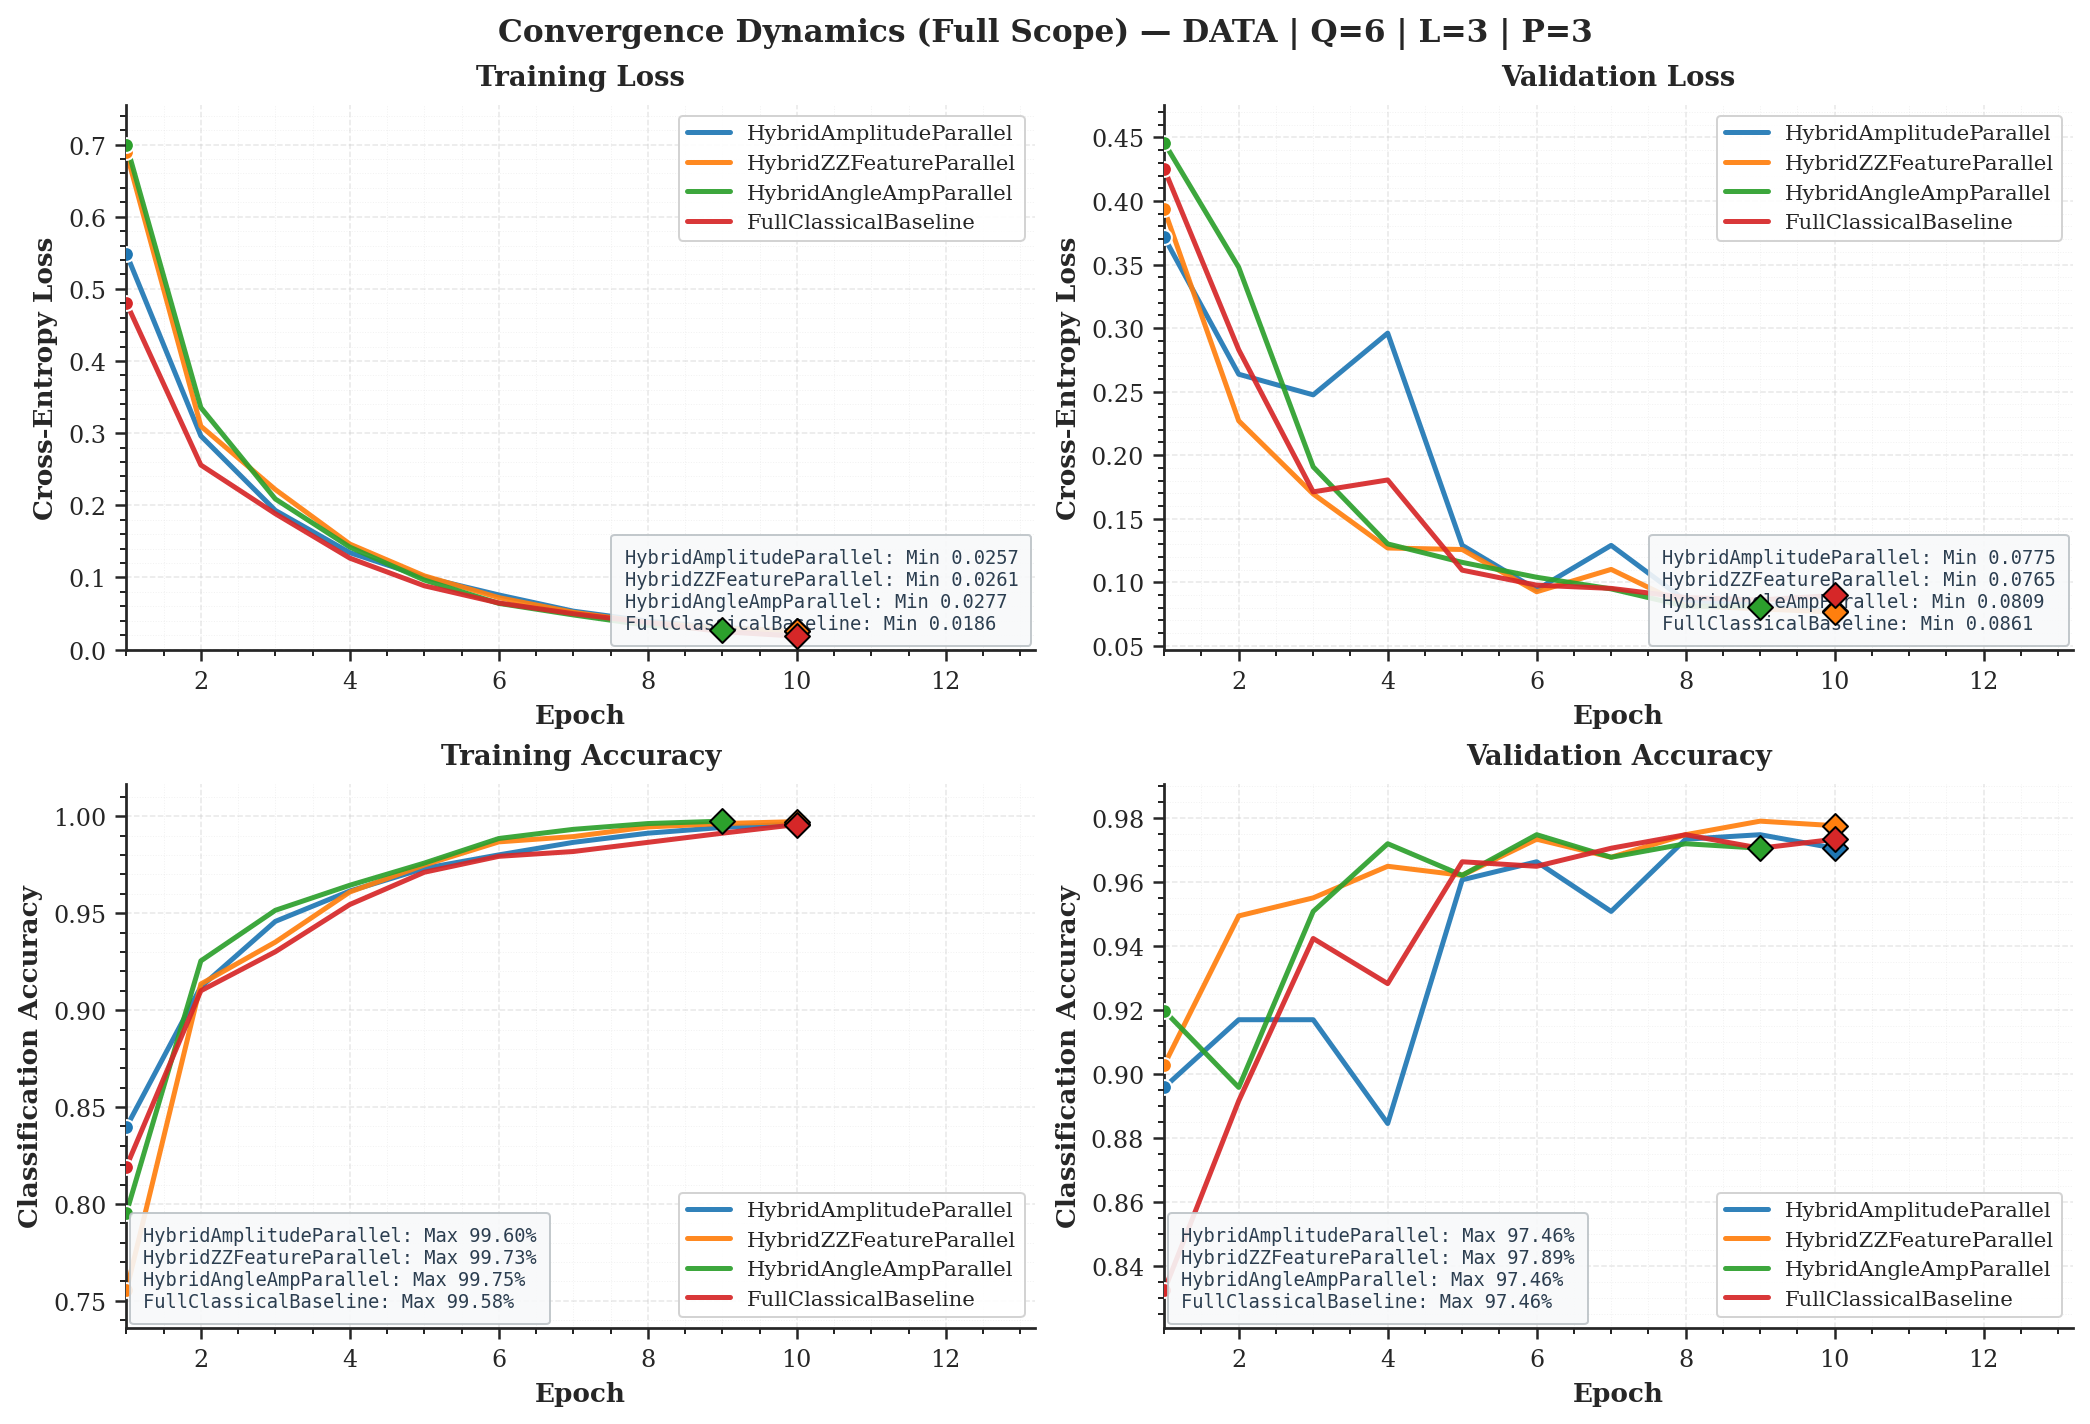

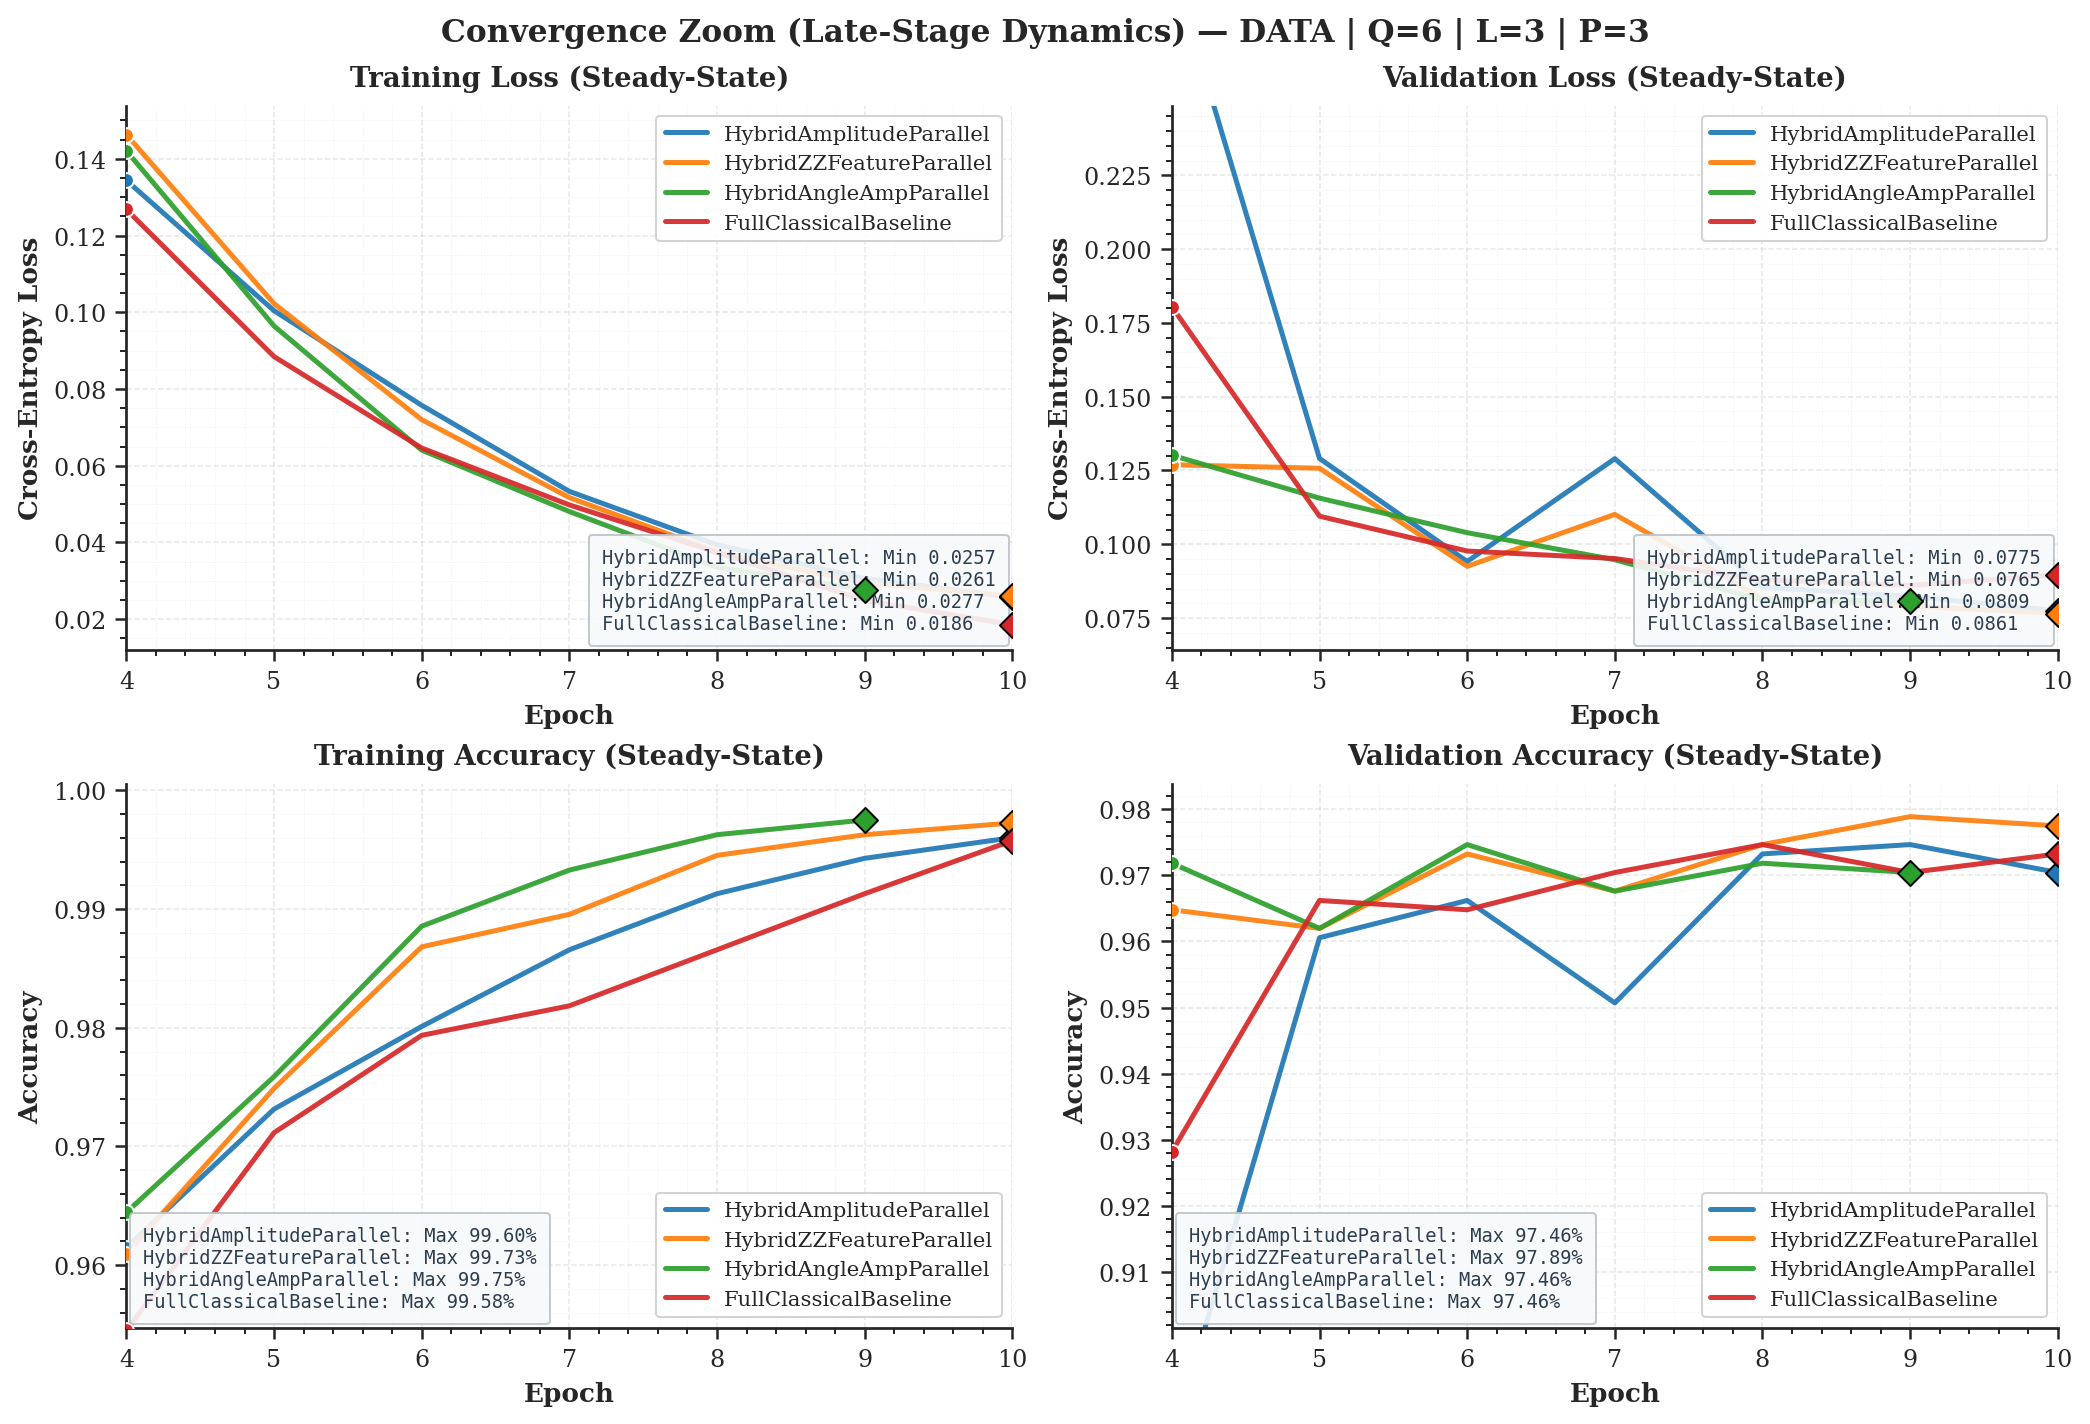

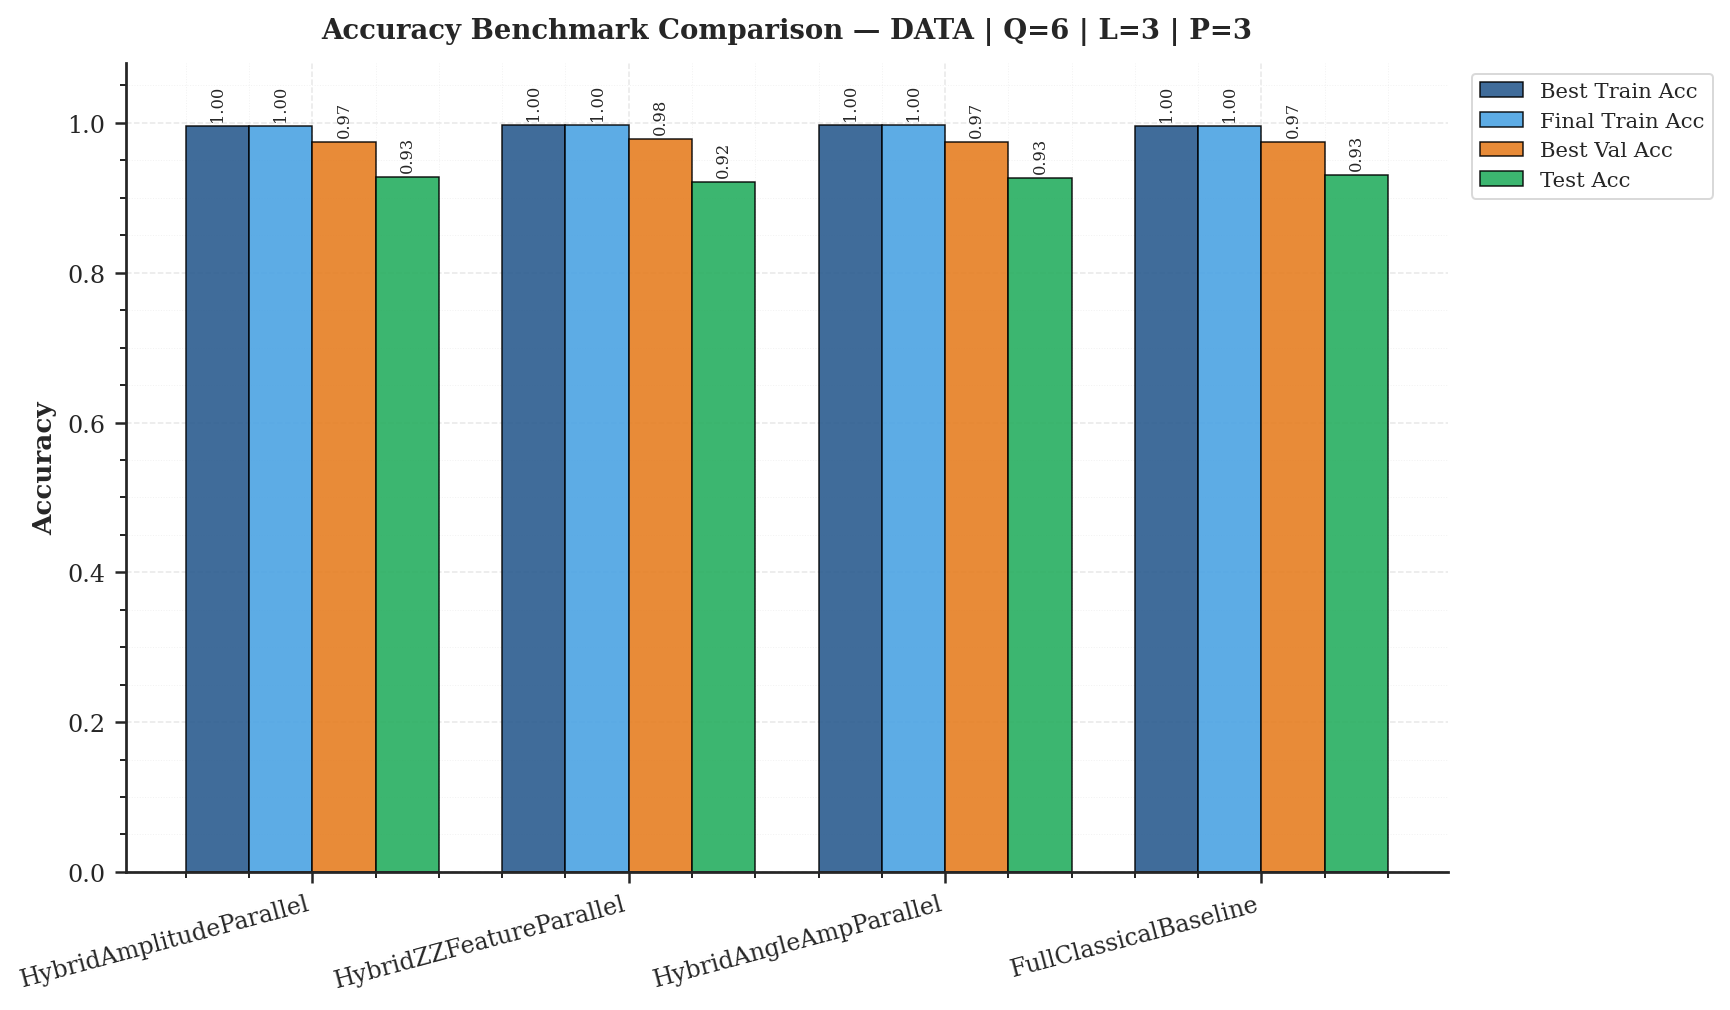

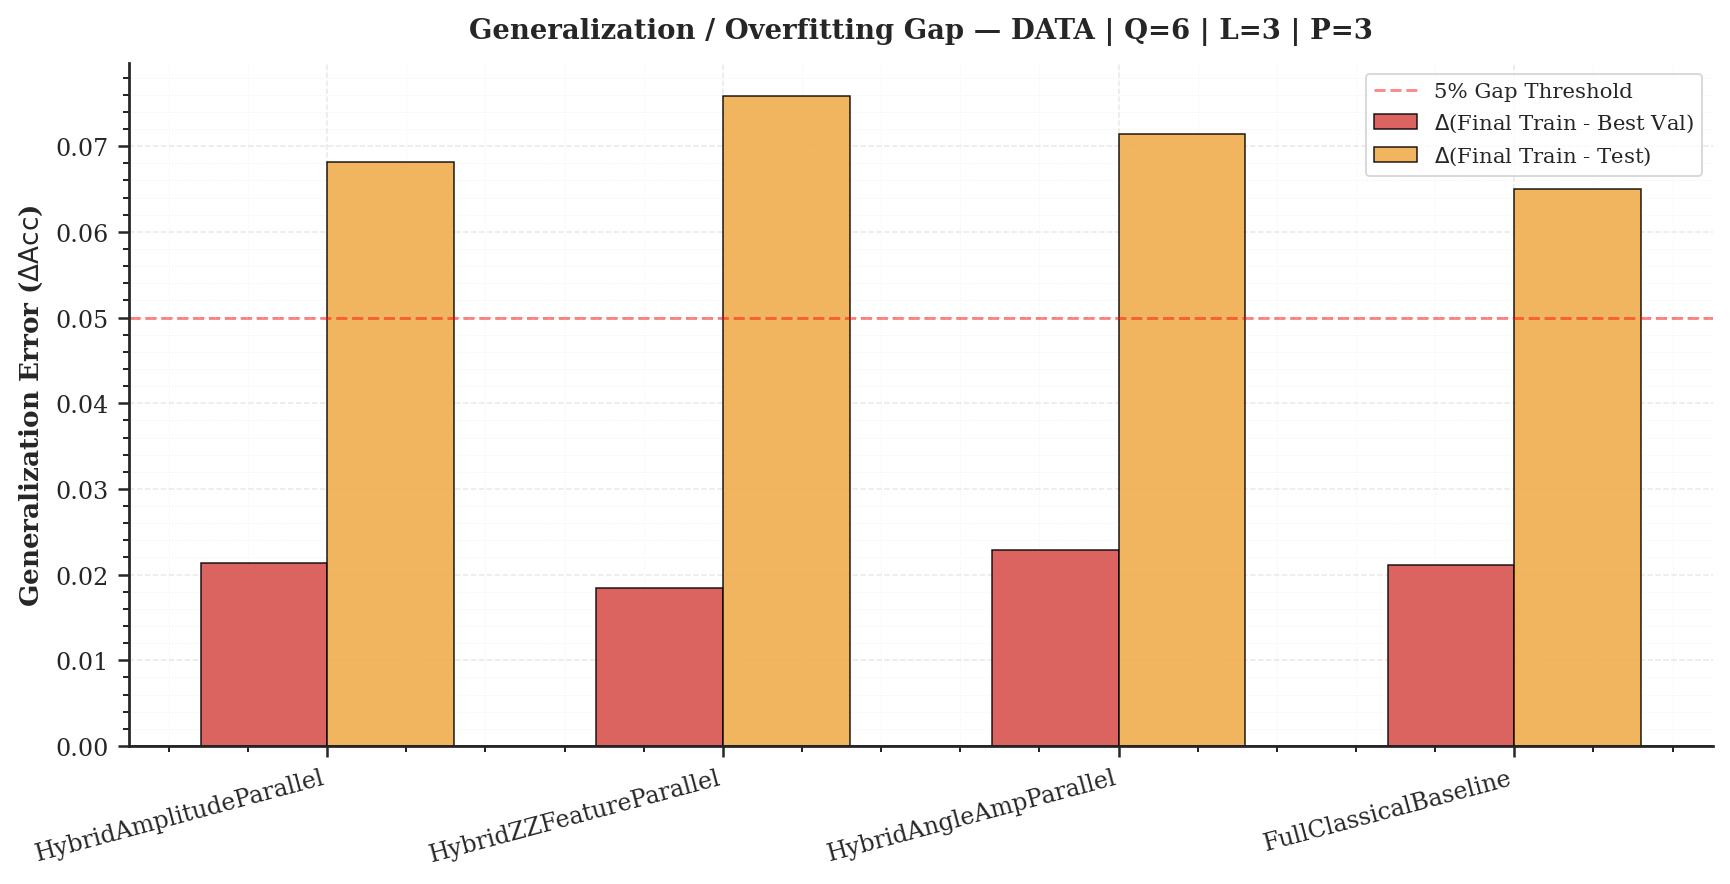

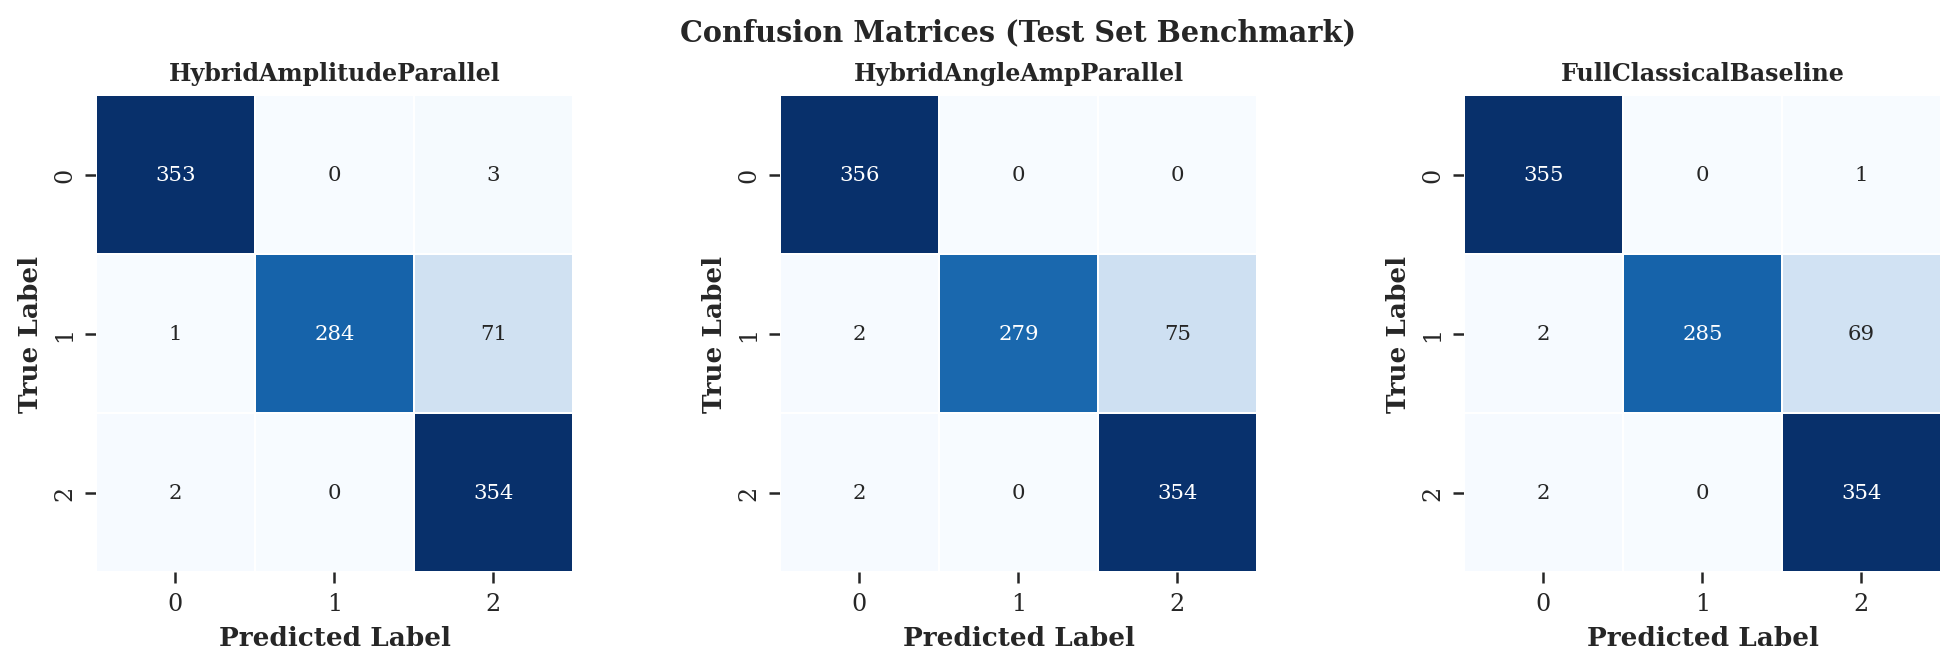


✅ Figures successfully generated at: D:\thesis\repu-of-git\hybrid_qml_image_classification\My_Quantum_Image_Project\results_hybrid_SeekThermal_parallel\figures-Car-Cat-Man Classification\test_005


In [60]:
plot_all_results_scientific(
    all_histories=all_histories,
    all_test_results=all_test_results,
    cfg=cfg,
    save_dir=Path(cfg.save_dir) / "figures-Car-Cat-Man Classification"
)

TypeError: plot_all_results_scientific() got an unexpected keyword argument 'dataset_name'

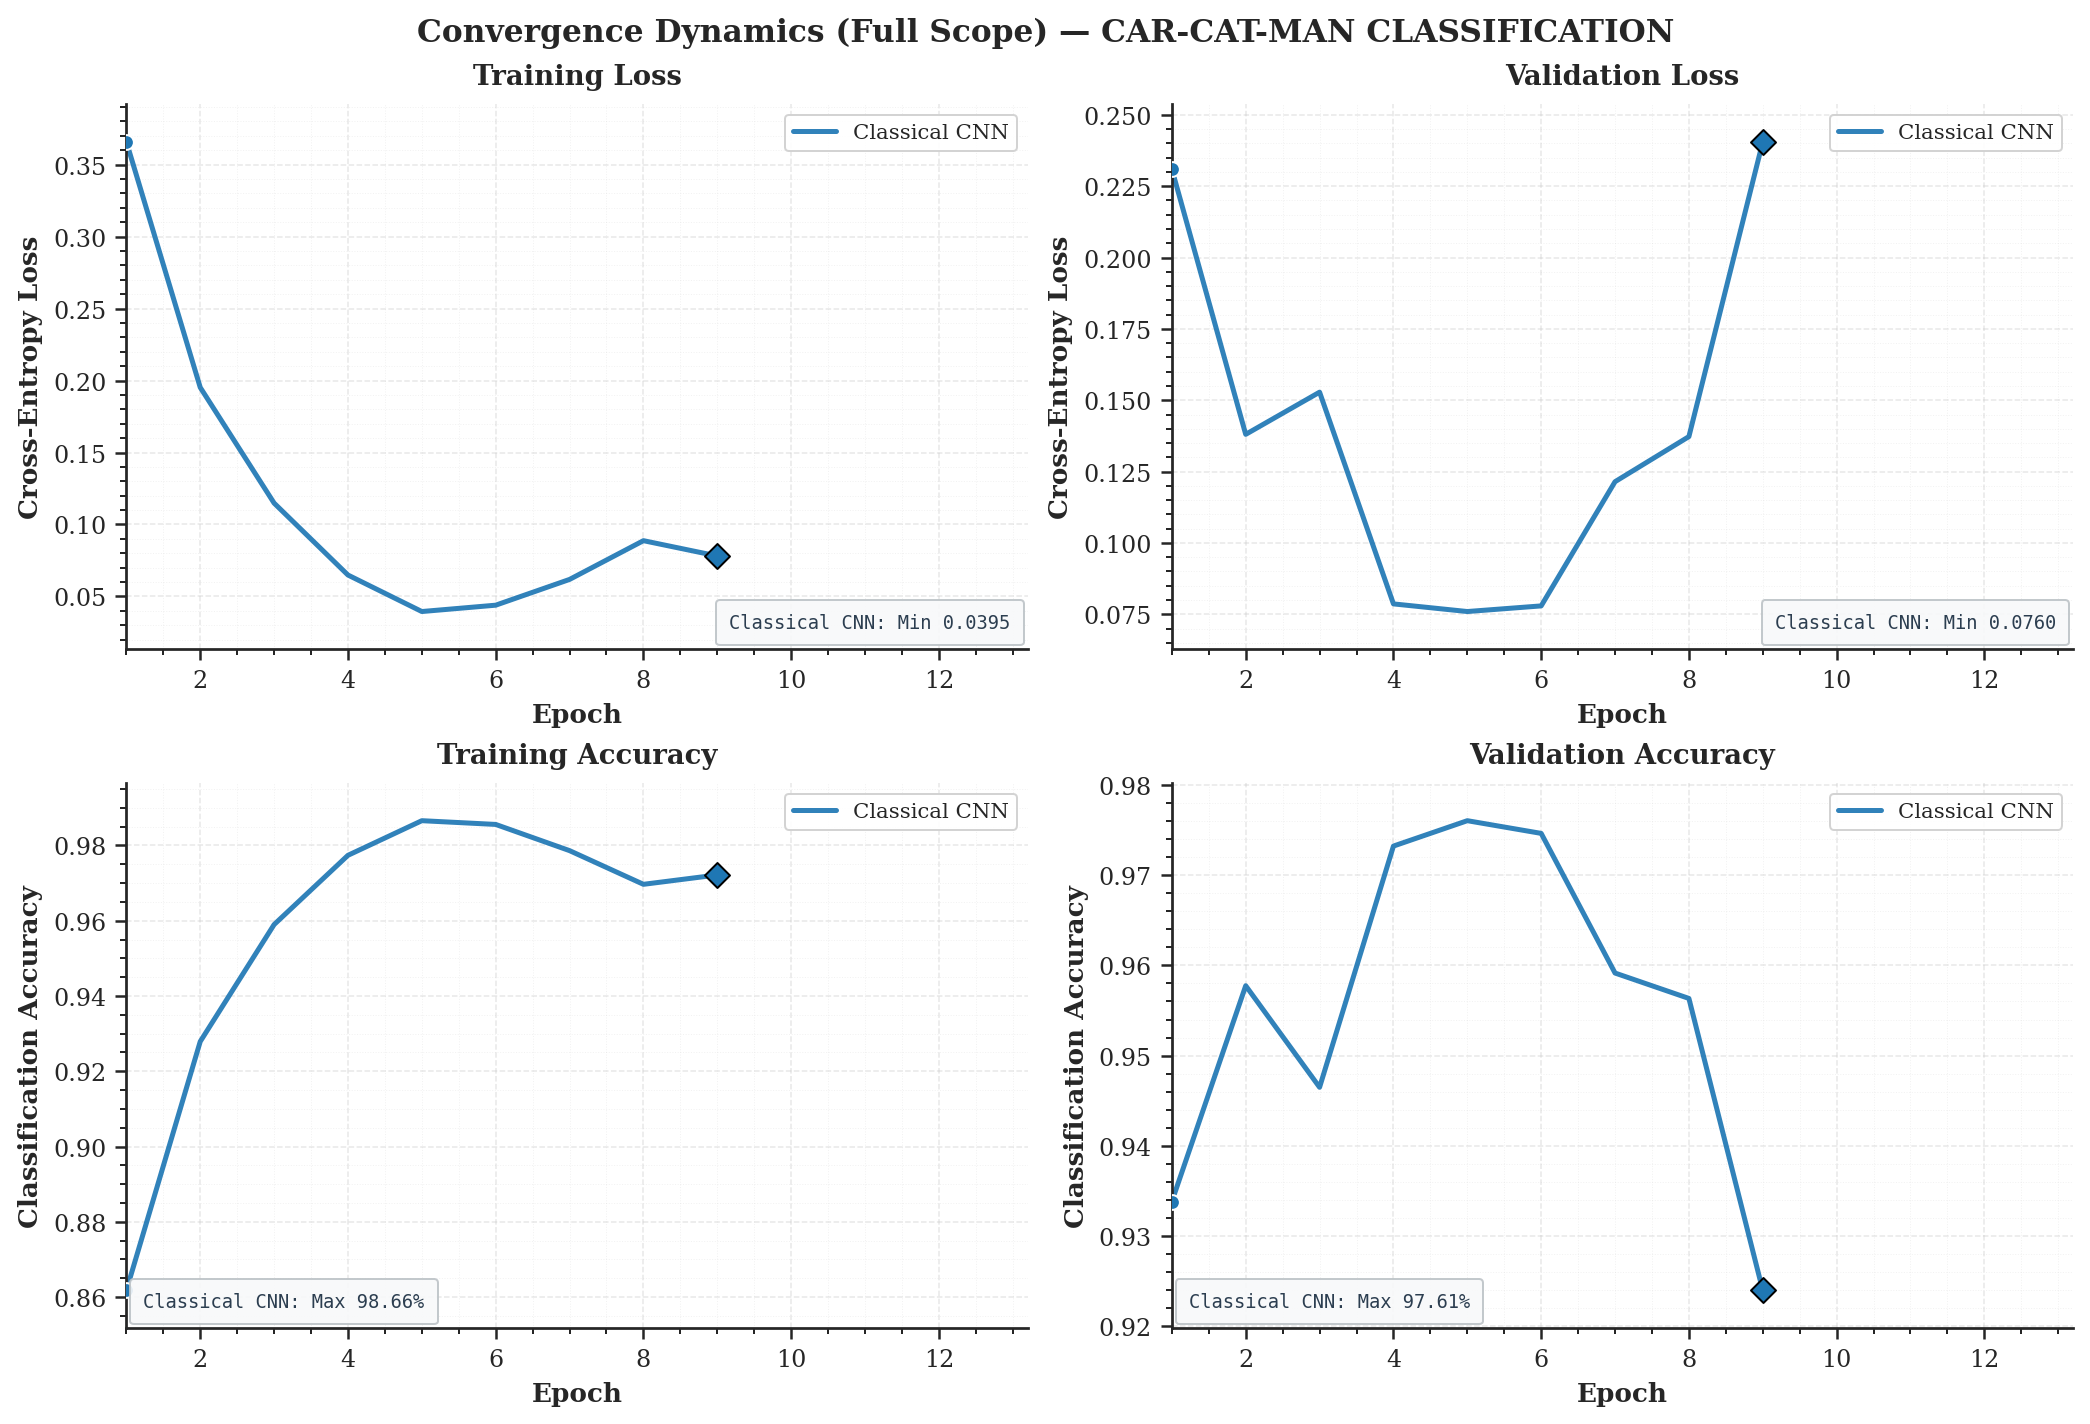

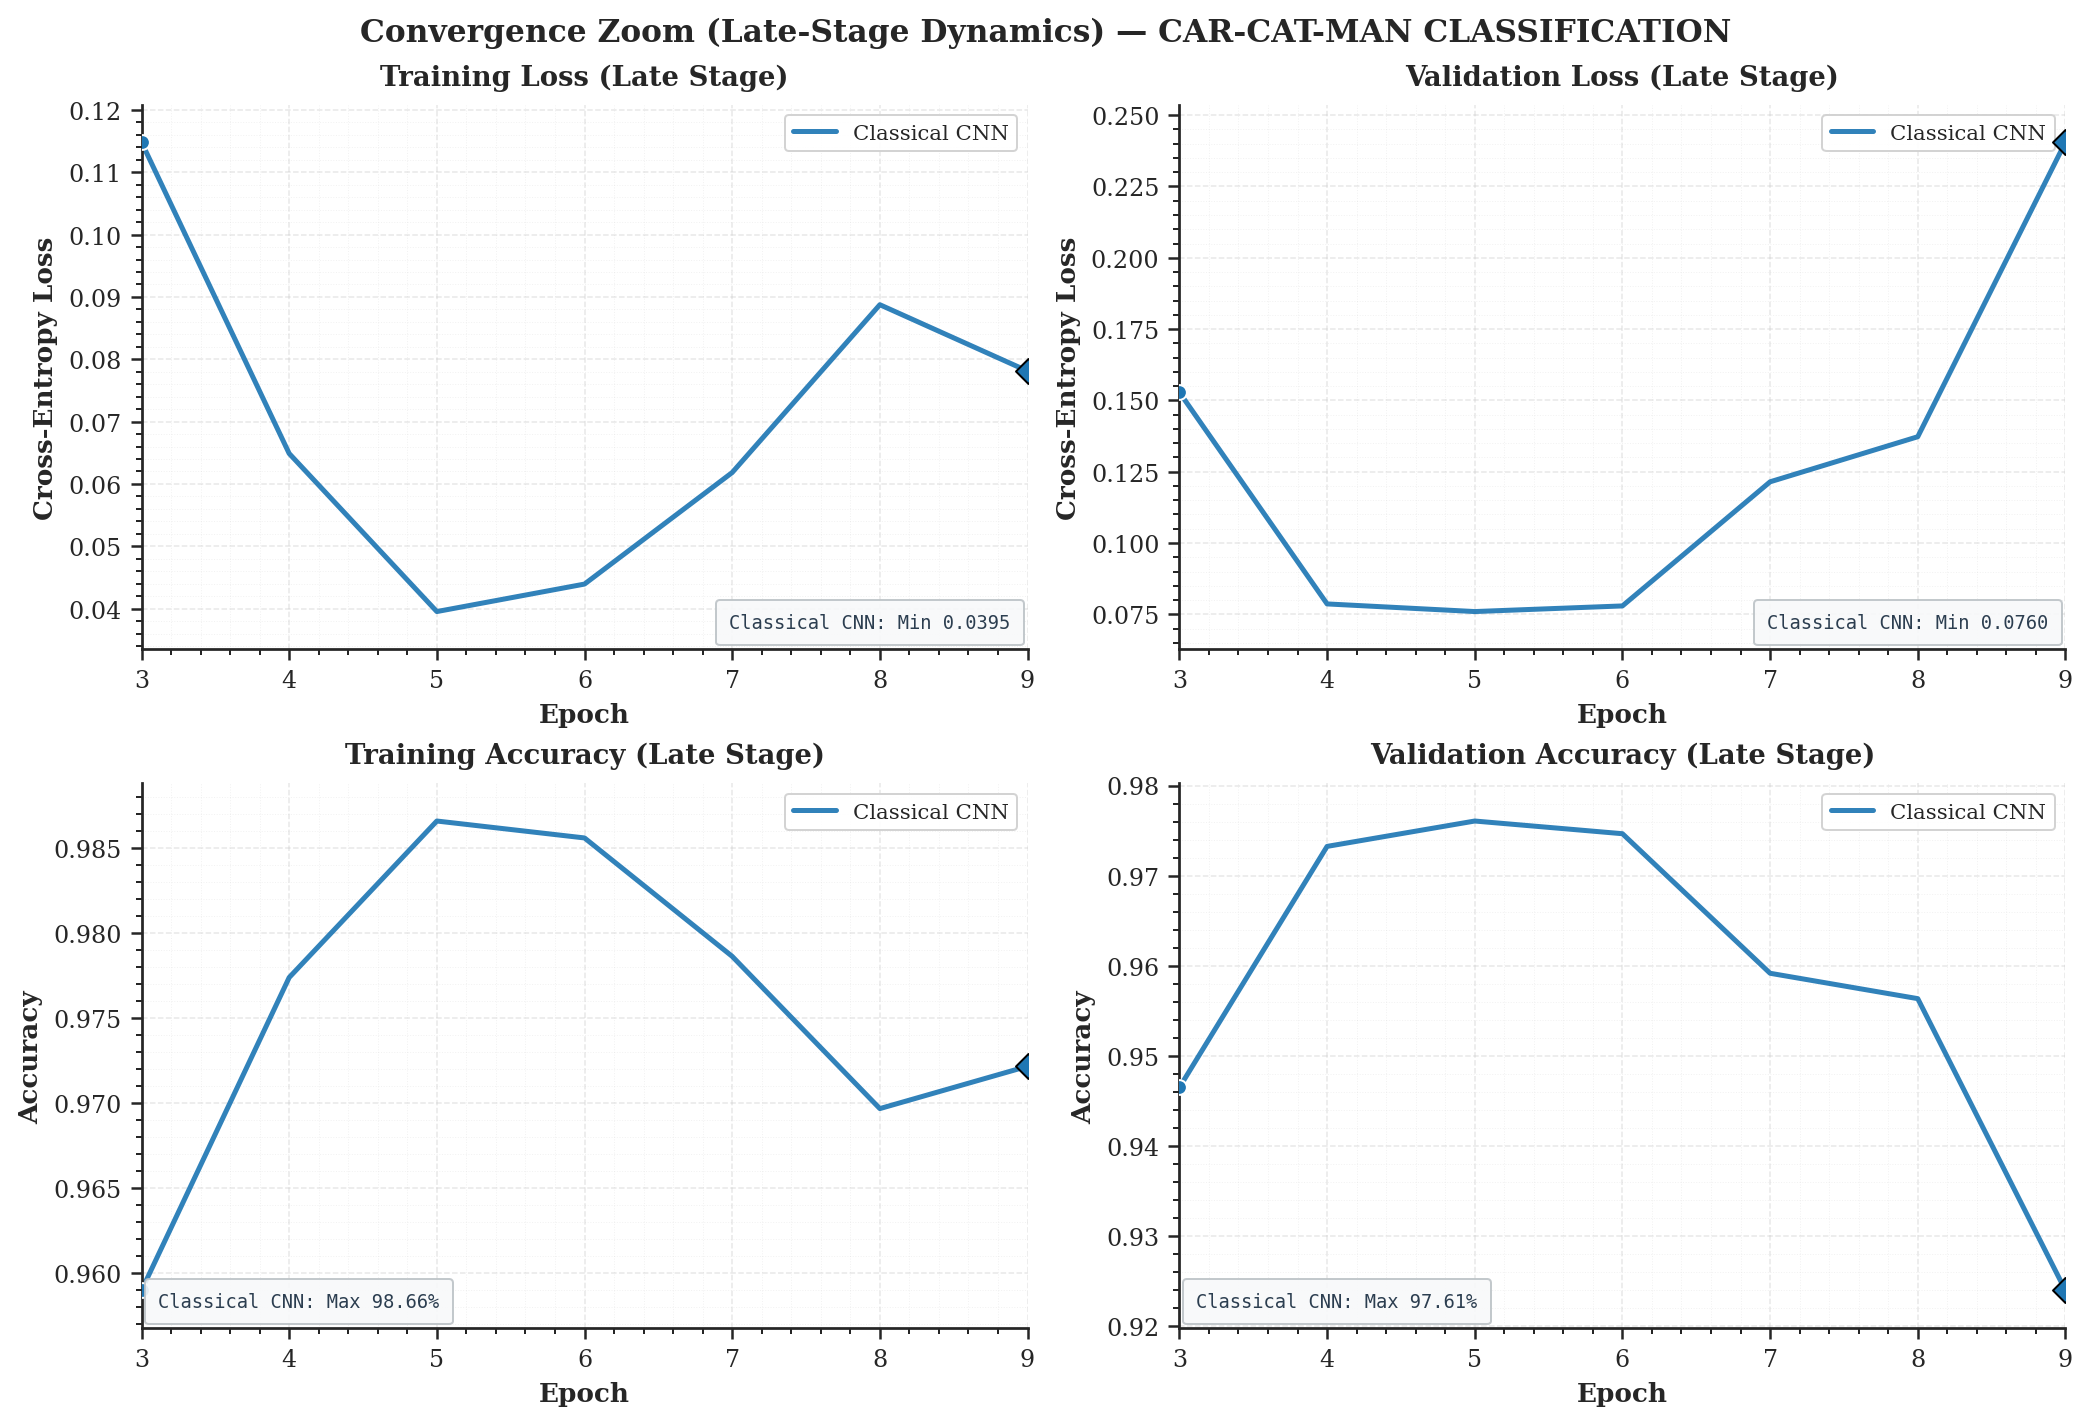

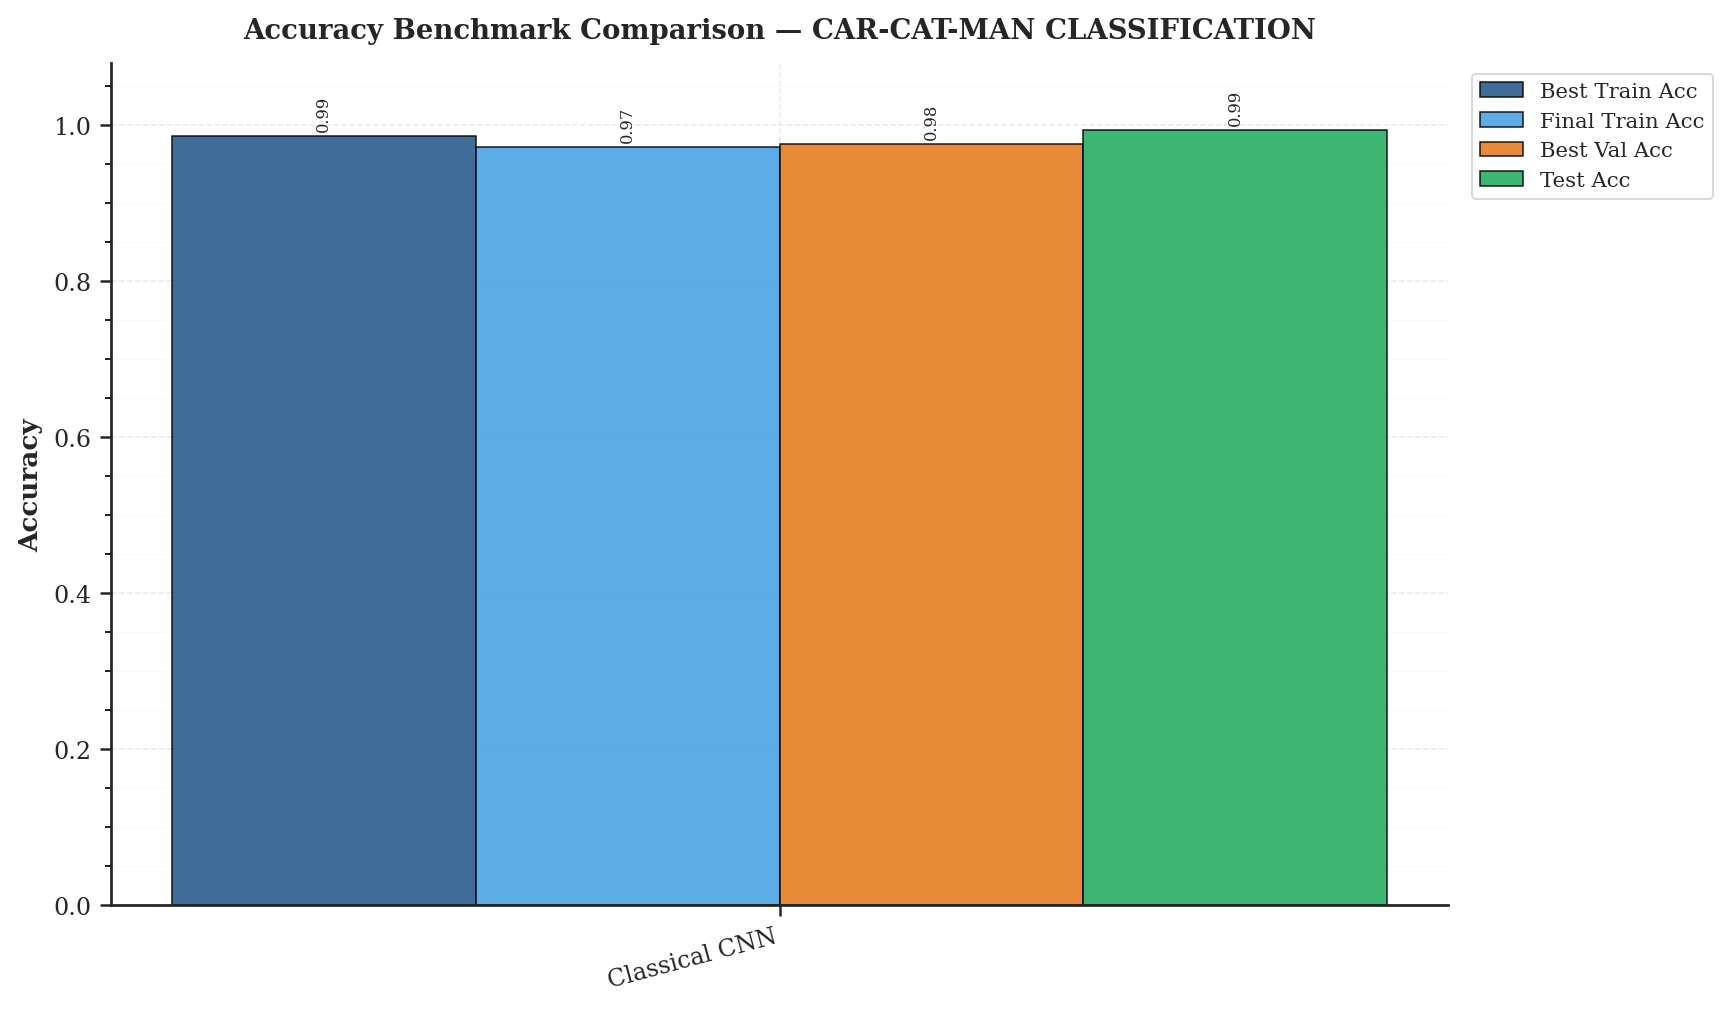

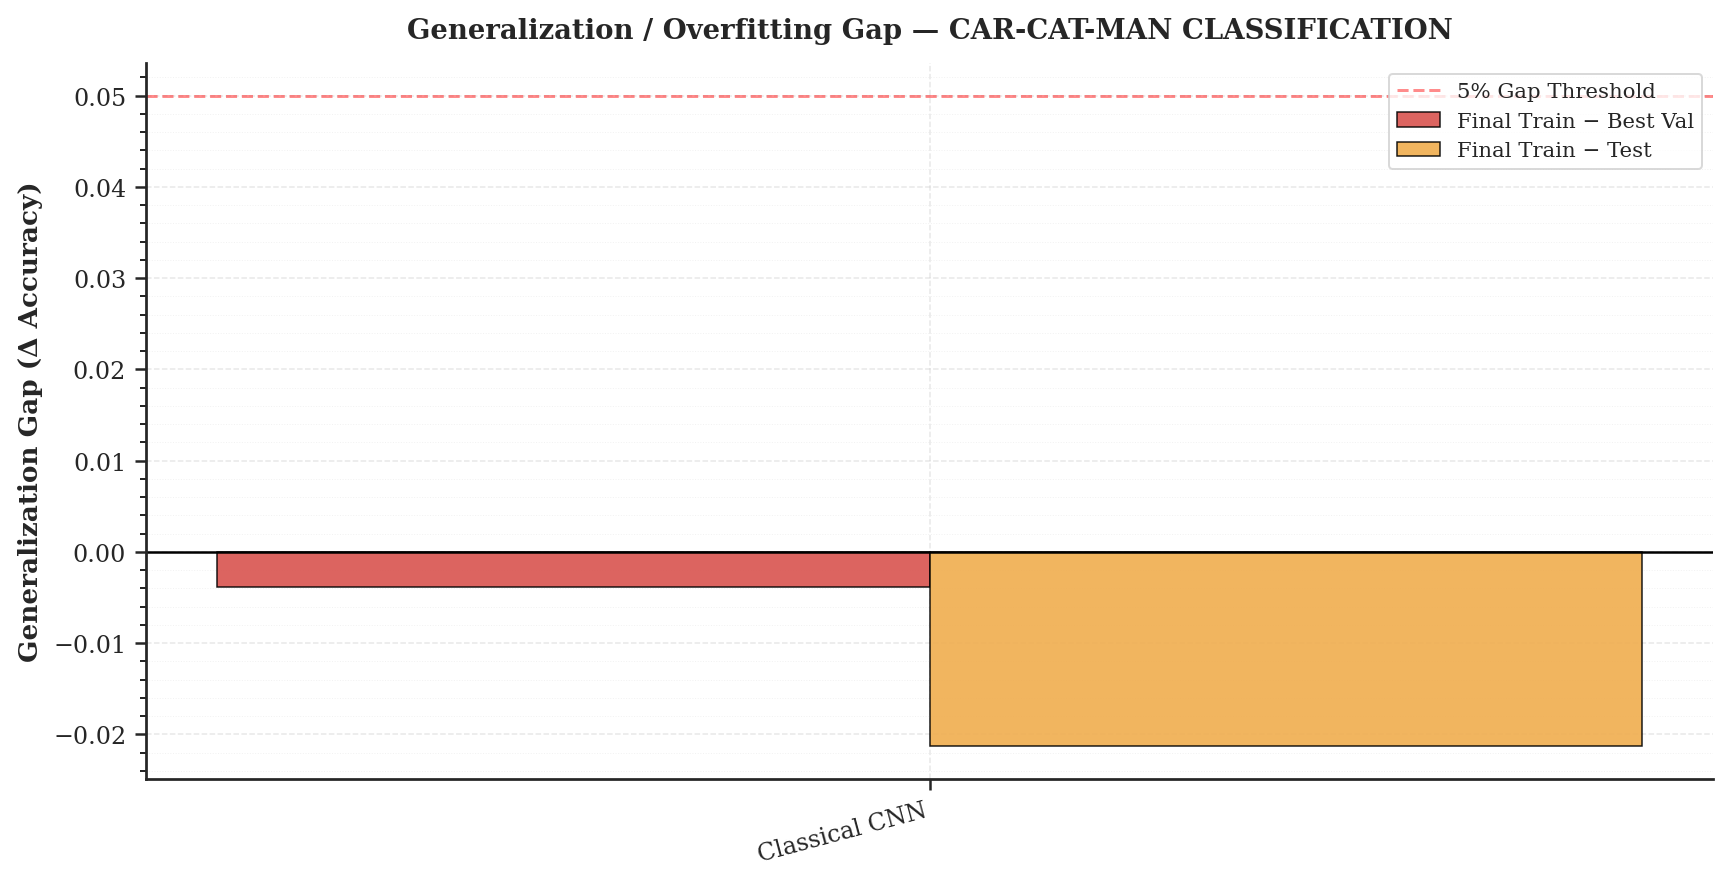

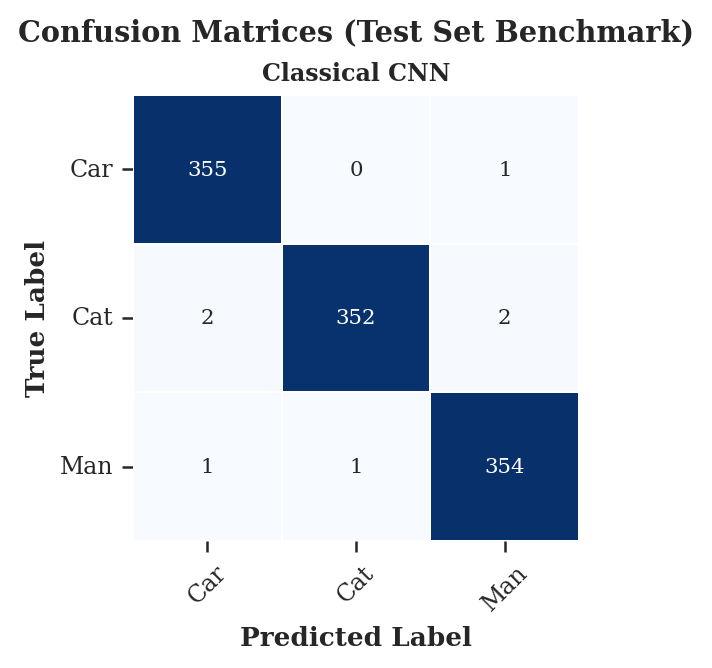


✅ Figures successfully generated at:
D:\thesis\repu-of-git\hybrid_qml_image_classification\My_Quantum_Image_Project\results_hybrid_SeekThermal_parallel\figures\test_002
